In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_32708\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_32708\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
# df2["Peritonitis"].value_counts()

In [54]:
# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)

In [55]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [56]:
# df2["Diagnosis"].corr(df2["Peritonitis"])

In [57]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

In [58]:
#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)
df2["Peritonitis"].value_counts()

0    189
1     49
Name: Peritonitis, dtype: int64

In [59]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.19028246913072036

In [60]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [61]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [62]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [63]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [64]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [65]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_32708\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_32708\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

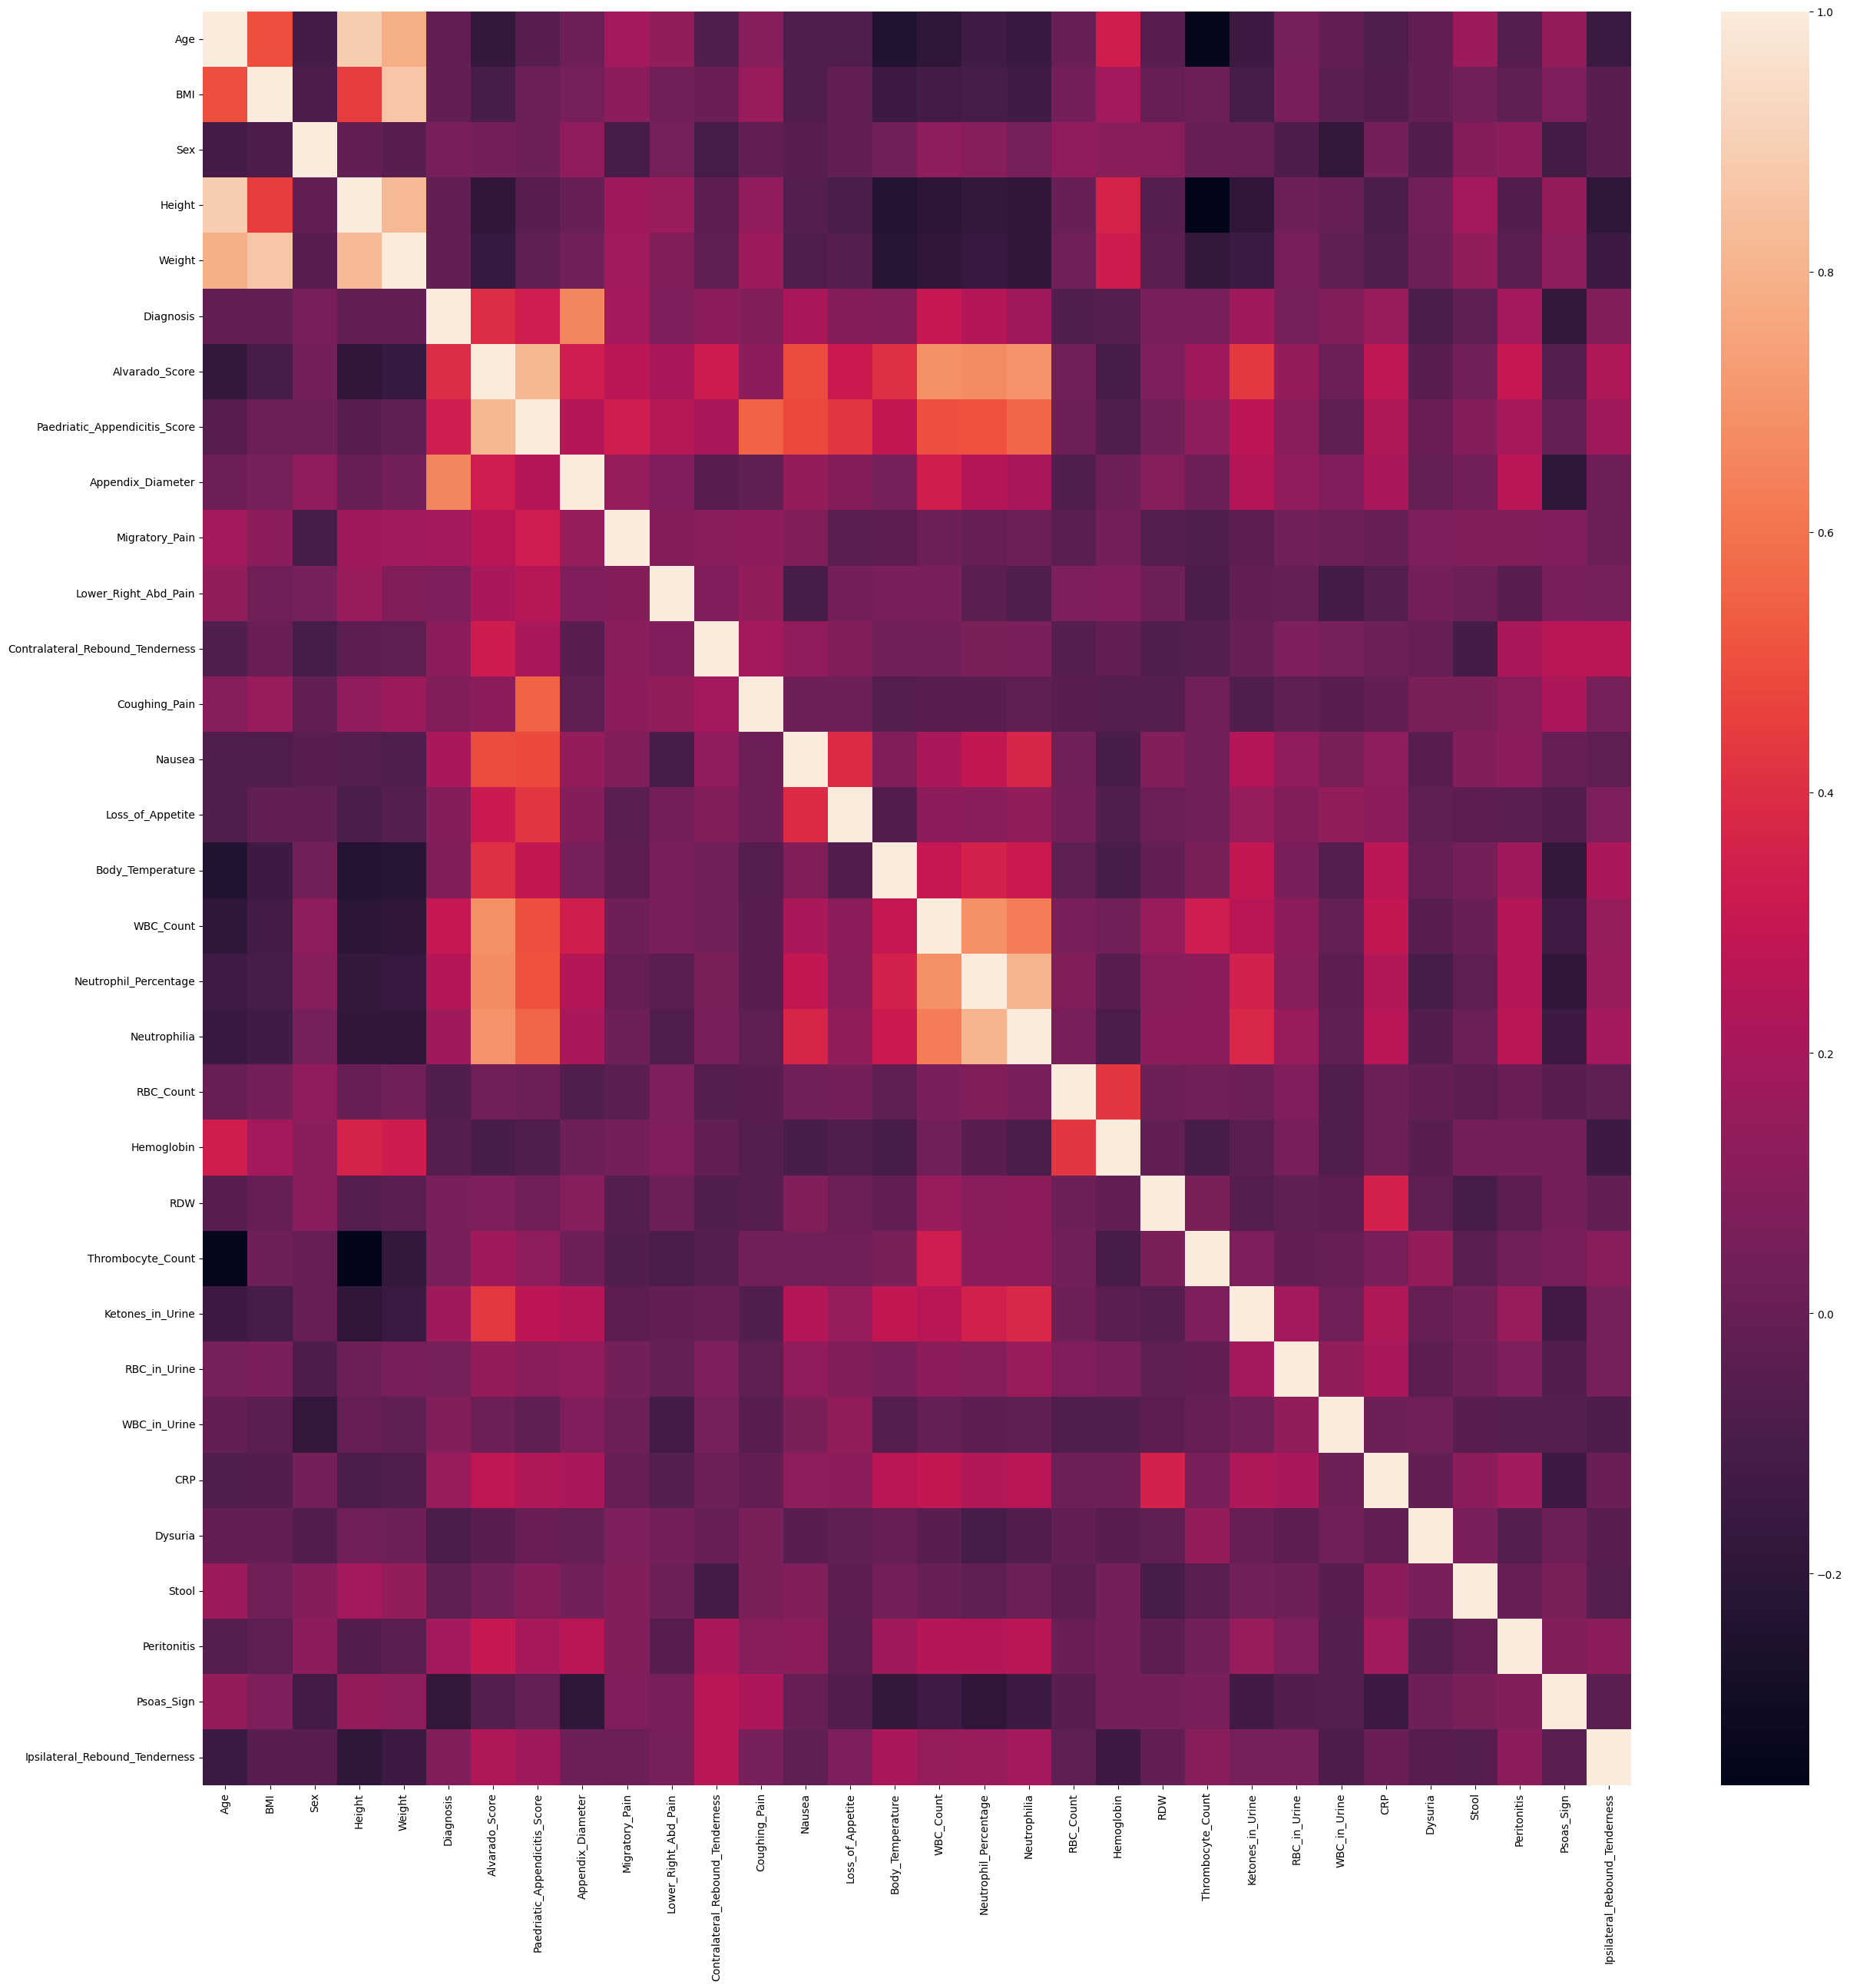

In [66]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [67]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [68]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [69]:
# dsafsf

In [70]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

# APPLYING SHAP VALUE FOR FEATURE SELECTION

In [71]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [72]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier(iterations=1500,learning_rate=0.1,depth=6,loss_function='Logloss')
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       1.00      0.94      0.97        31

    accuracy                           0.96        48
   macro avg       0.95      0.97      0.96        48
weighted avg       0.96      0.96      0.96        48



C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:21:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [73]:
# !pip install shap
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)

[15:21:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

PermutationExplainer explainer: 49it [00:17,  2.71it/s]                                                                


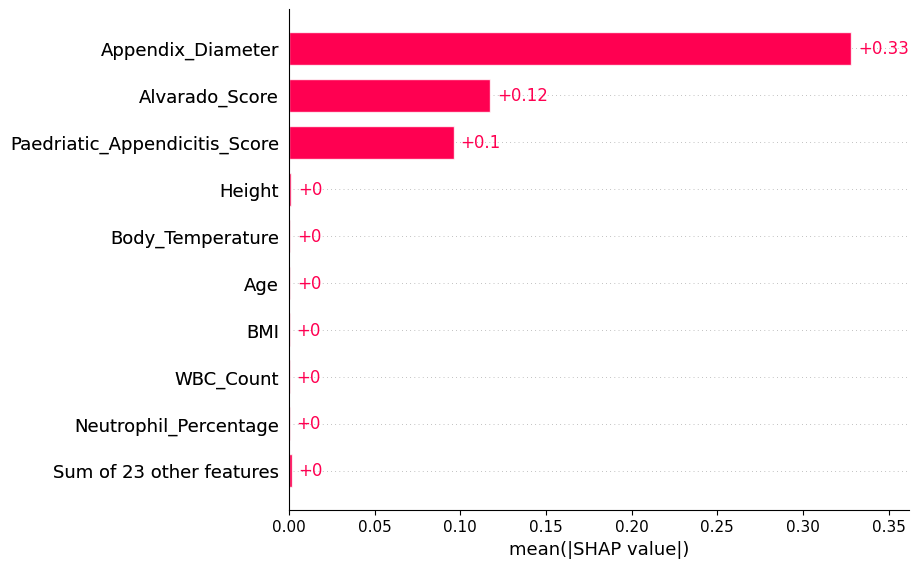

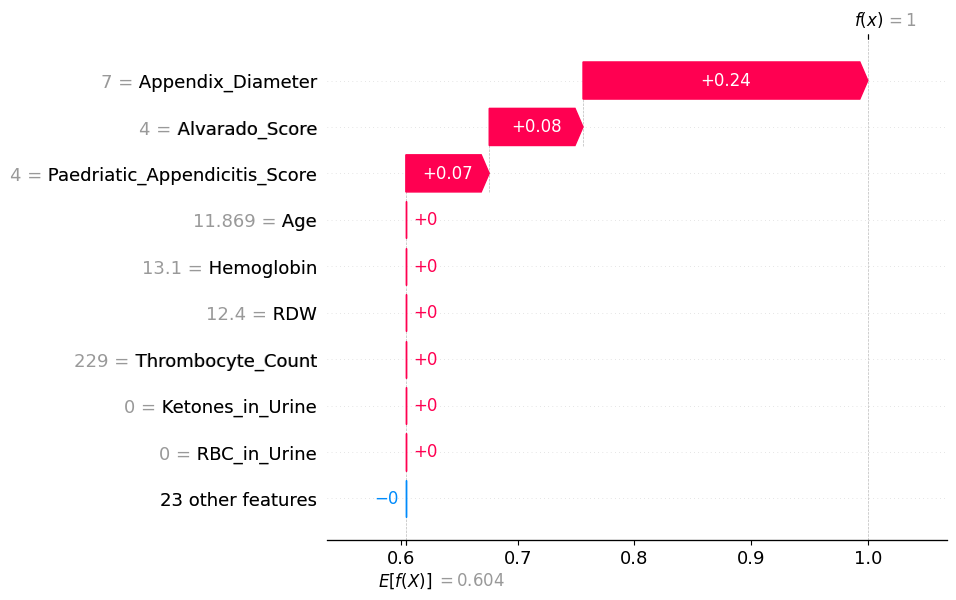

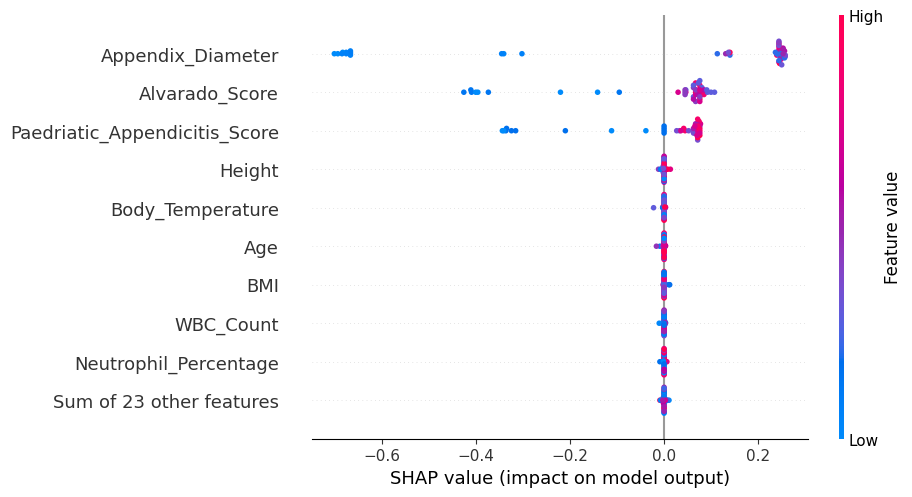

In [74]:
shap.plots.bar(shap_values)
shap.plots.waterfall(shap_values[0])
shap.plots.beeswarm(shap_values)

In [75]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score"]

In [76]:
cols

['Appendix_Diameter', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score']

In [77]:
cols.append("Diagnosis")

In [78]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [79]:
# df4 = df.dropna()
# aaaaaaaaaa

In [80]:
# df4.shape
df2["Free_Fluids"].value_counts()

0    142
1     96
Name: Free_Fluids, dtype: int64

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [82]:
type(cols)

list

In [83]:
df = df.loc[:,cols]
# print(cols)

In [84]:
df

,Appendix_Diameter,Alvarado_Score,Paedriatic_Appendicitis_Score,Diagnosis
0,7.1,4.0,3.0,1
1,NaN,5.0,4.0,0
2,NaN,5.0,3.0,0
3,NaN,7.0,6.0,0
4,7.0,5.0,6.0,1
...,...,...,...,...
777,7.5,8.0,7.0,1
778,NaN,5.0,3.0,1
779,NaN,5.0,3.0,1
780,14.0,9.0,8.0,1


<class 'pandas.core.frame.DataFrame'>
Int64Index: 477 entries, 0 to 781
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Appendix_Diameter              477 non-null    float64
 1   Alvarado_Score                 477 non-null    float64
 2   Paedriatic_Appendicitis_Score  477 non-null    float64
 3   Diagnosis                      477 non-null    int32  
dtypes: float64(3), int32(1)
memory usage: 16.8 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 477 entries, 0 to 781
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Appendix_Diameter              477 non-null    float64
 1   Alvarado_Score                 477 non-null    float64
 2   Paedriatic_Appendicitis_Score  477 non-null    float64
 3   Diagnosis                      477 non-null    int32  
dtypes: float64(3), i

1    355
0    122
Name: Diagnosis, dtype: int64

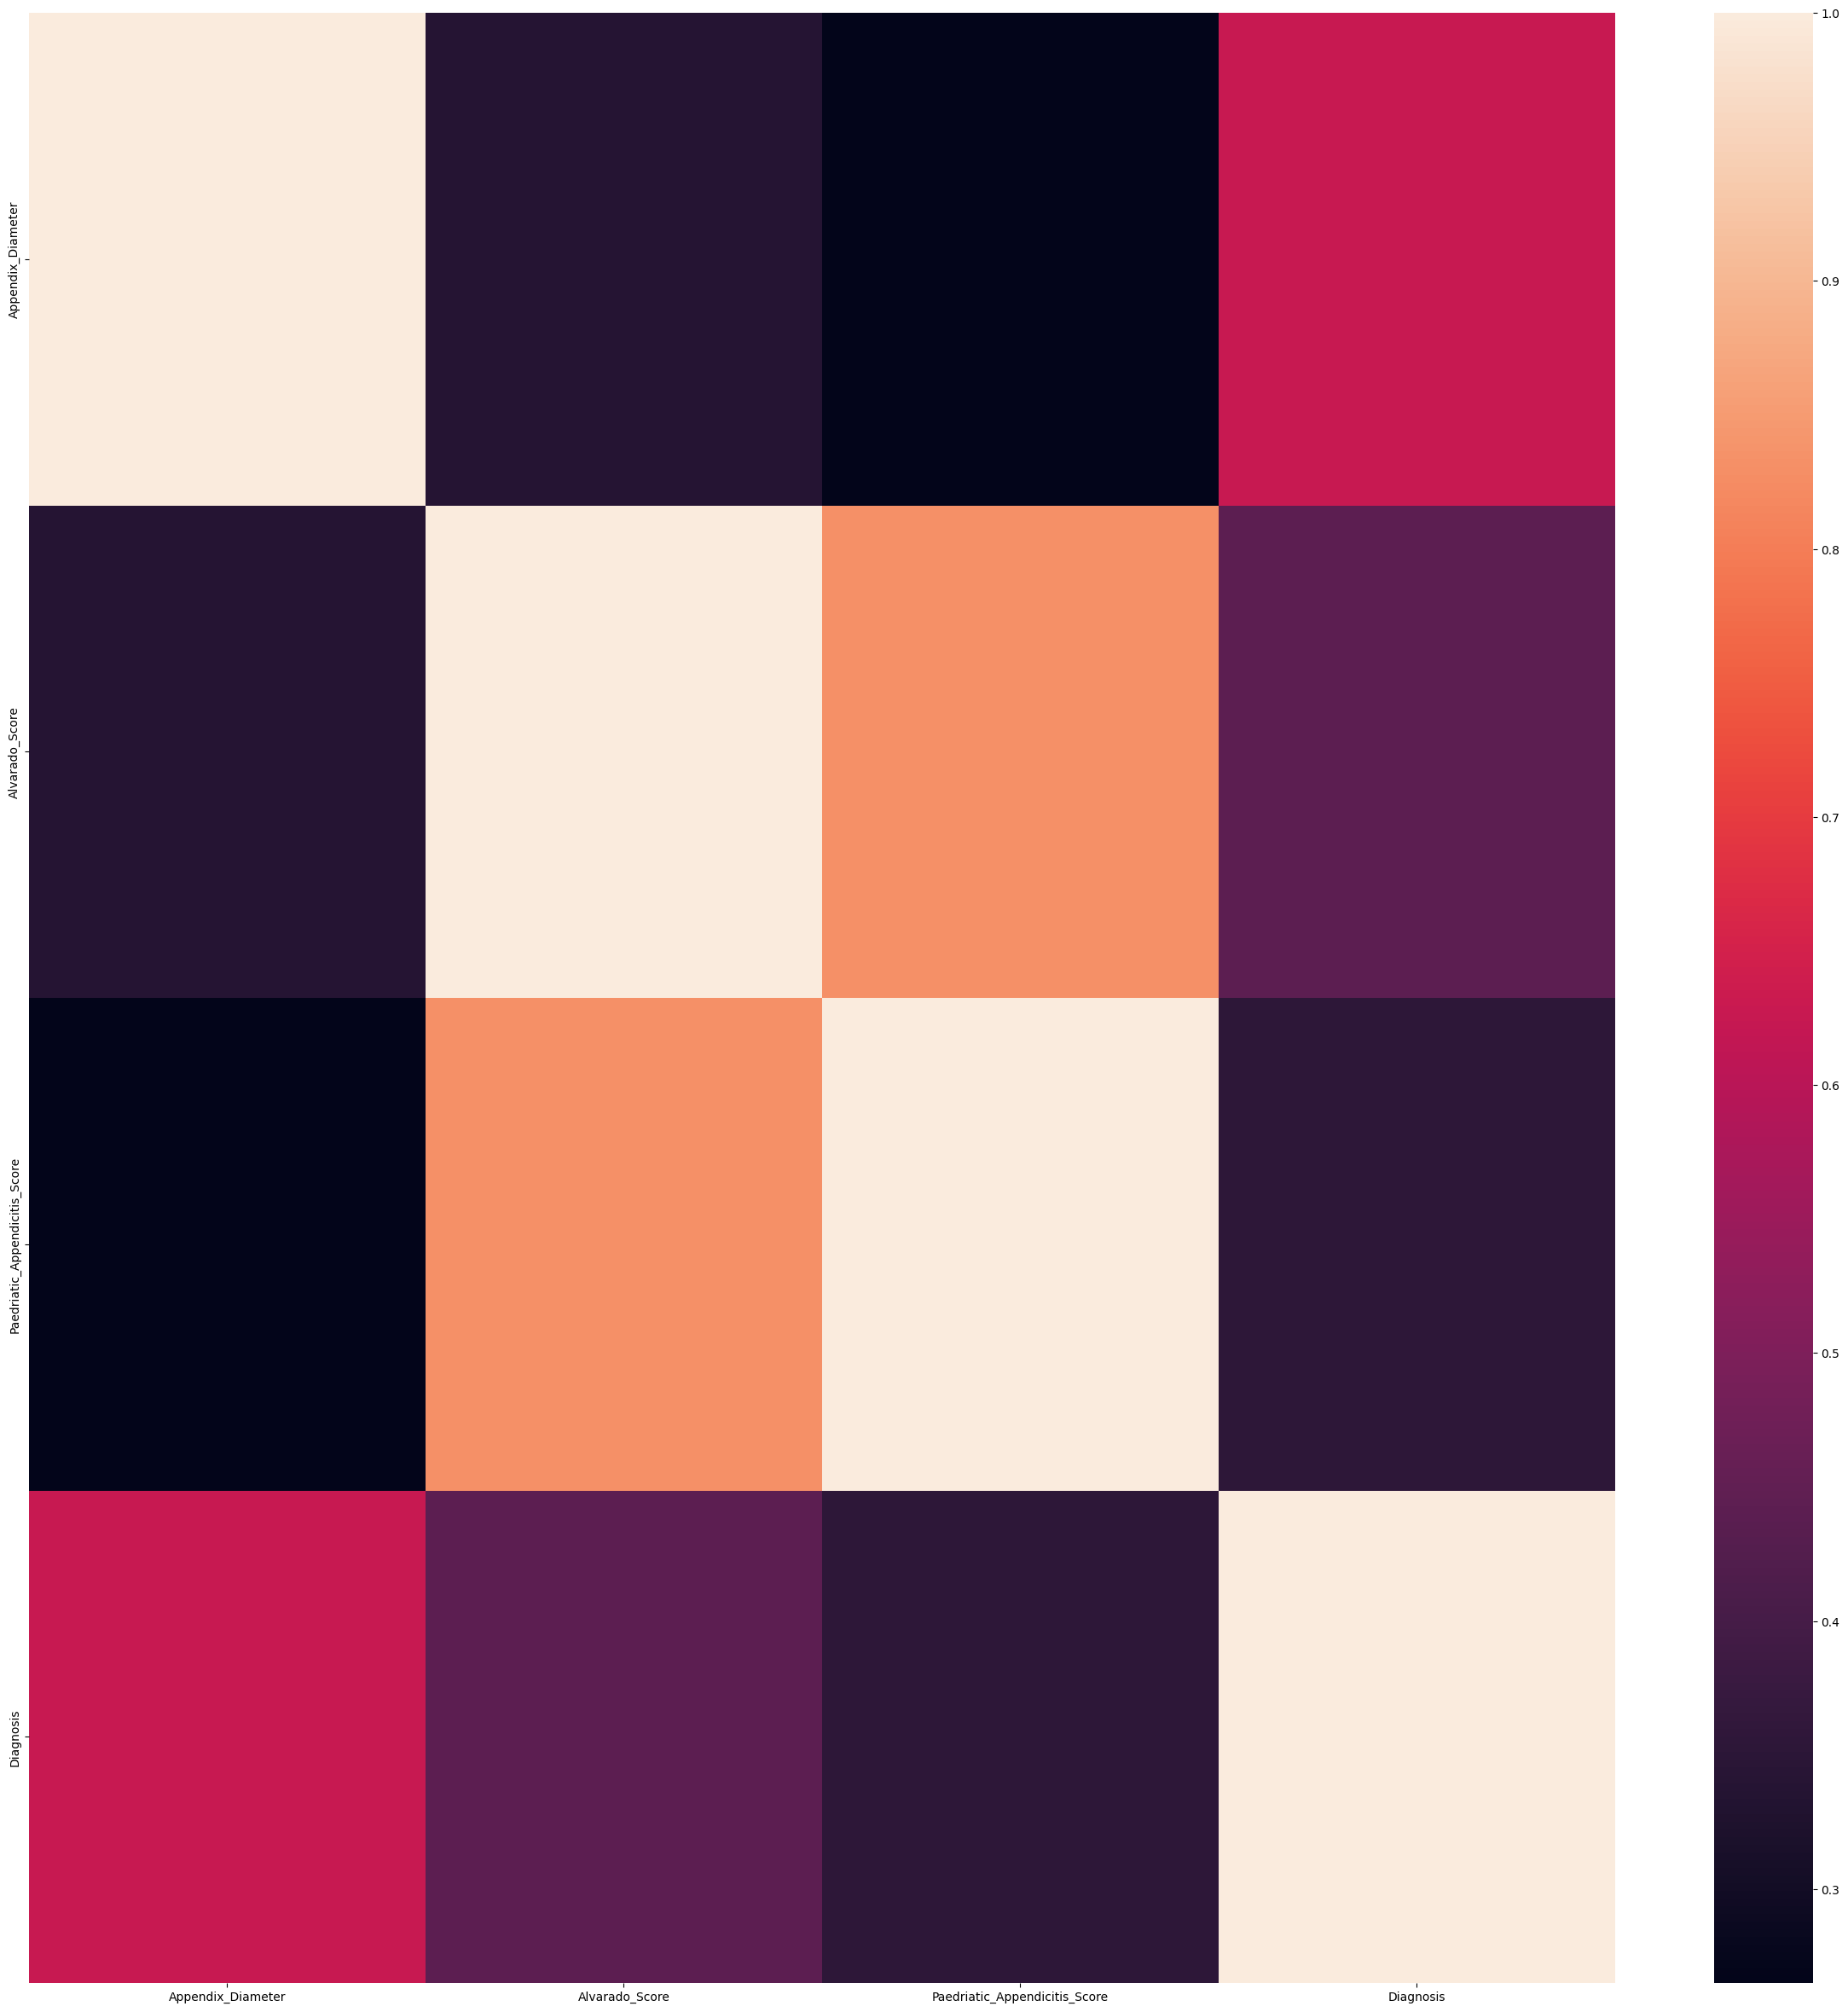

In [85]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)



# correlation of different columns with each other
df.corr()


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


# df2["WBC_in_Urine"].value_counts()


# In[23]:


# df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


# df.info()


# In[26]:


# df2["Sex"].value_counts()


# In[27]:


# df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


# df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


# df.info()


# In[30]:


# df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


# df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
# df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


# df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


# df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
# df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


# df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


# df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
# df2["Coughing_Pain"].value_counts()


# In[36]:


# df2["Nausea"].value_counts(dropna = False)


# In[37]:


# df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
# df2["Nausea"].value_counts()


# In[38]:


# df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


# df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
# df2["Loss_of_Appetite"].value_counts()


# In[40]:


# df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


# df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
# df2["Neutrophilia"].value_counts()


# In[42]:


# df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
# df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


# df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
# df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


# df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
# df2["Dysuria"].value_counts()


# In[51]:


# df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


# enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
# enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
# df2["Stool"] = enc.fit_transform(df2[["Stool"]])
# df2["Stool"].value_counts(dropna = False)


# In[53]:


# df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


# df2["Psoas_Sign"].value_counts()


# In[60]:


# df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


# df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


# df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [86]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(477, 3)

In [87]:
y.value_counts()

1    355
0    122
Name: Diagnosis, dtype: int64

In [88]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 477 entries, 0 to 781
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Appendix_Diameter              477 non-null    float64
 1   Alvarado_Score                 477 non-null    float64
 2   Paedriatic_Appendicitis_Score  477 non-null    float64
dtypes: float64(3)
memory usage: 14.9 KB


In [89]:
from sklearn.model_selection import train_test_split

In [90]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [91]:
x_train.shape

(381, 3)

In [92]:
# y_train.value_counts()

In [93]:
# col
x_train.columns

Index(['Appendix_Diameter', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score'], dtype='object')

In [94]:
y_test.value_counts()
y_train.value_counts()

1    280
0    101
Name: Diagnosis, dtype: int64

In [95]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.97      0.97      0.97        75

    accuracy                           0.96        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.96      0.96      0.96        96



In [96]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.94 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.02
TEST_ROC_AUC - Mean: 0.97 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.98 ± 0.01
TEST_PRECISION - Mean: 0.97 ± 0.02
TEST_RECALL - Mean: 0.96 ± 0.03


In [97]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9874
Fold 2: AUPR = 0.9987
Fold 3: AUPR = 0.9885
Fold 4: AUPR = 0.9804
Fold 5: AUPR = 0.9897

Average AUPR: 0.99 +- 0.01


In [98]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB = NB.fit(x_train,y_train)
y_pred = NB.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76        21
           1       0.93      0.93      0.93        75

    accuracy                           0.90        96
   macro avg       0.85      0.85      0.85        96
weighted avg       0.90      0.90      0.90        96



In [99]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(NB,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.88 ± 0.02
TEST_F1 - Mean: 0.91 ± 0.02
TEST_ROC_AUC - Mean: 0.94 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.98 ± 0.01
TEST_PRECISION - Mean: 0.93 ± 0.03
TEST_RECALL - Mean: 0.90 ± 0.02


In [100]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9874
Fold 2: AUPR = 0.9987
Fold 3: AUPR = 0.9885
Fold 4: AUPR = 0.9804
Fold 5: AUPR = 0.9897

Average AUPR: 0.99 +- 0.01


In [101]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.97      0.97      0.97        75

    accuracy                           0.96        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.96      0.96      0.96        96



In [102]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.00
TEST_PRECISION - Mean: 0.97 ± 0.02
TEST_RECALL - Mean: 0.96 ± 0.02


In [103]:
# This will not work here

# from sklearn.metrics import precision_recall_curve,auc
# def calc_aupr():
#     # Initialize list to store AUPR values for each fold
#     aupr_list = []
 
#     X = x
#     # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Train the model
#         model.fit(X_train, y_train)

#         # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#         # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#         # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#         # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     std_aupr = np.std(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

# calc_aupr()

In [104]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        21
           1       0.97      0.96      0.97        75

    accuracy                           0.95        96
   macro avg       0.92      0.93      0.93        96
weighted avg       0.95      0.95      0.95        96



In [105]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.96 ± 0.01
TEST_F1 - Mean: 0.97 ± 0.01
TEST_ROC_AUC - Mean: 0.95 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.97 ± 0.01
TEST_PRECISION - Mean: 0.98 ± 0.01
TEST_RECALL - Mean: 0.97 ± 0.01


In [106]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9831
Fold 2: AUPR = 0.9985
Fold 3: AUPR = 0.9838
Fold 4: AUPR = 0.9805
Fold 5: AUPR = 0.9779

Average AUPR: 0.9848 +- 0.01


In [107]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.97      0.99      0.98        74

    accuracy                           0.97        96
   macro avg       0.96      0.95      0.96        96
weighted avg       0.97      0.97      0.97        96



In [108]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.49 ± 0.18
SCORE_TIME - Mean: 0.06 ± 0.01
TEST_ACCURACY - Mean: 0.96 ± 0.02
TEST_F1 - Mean: 0.97 ± 0.02
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00


In [109]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9960
Fold 2: AUPR = 0.9990
Fold 3: AUPR = 0.9909
Fold 4: AUPR = 0.9944
Fold 5: AUPR = 0.9978

Average AUPR: 0.9956 +- 0.00


In [110]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        21
           1       0.99      0.97      0.98        75

    accuracy                           0.97        96
   macro avg       0.95      0.96      0.96        96
weighted avg       0.97      0.97      0.97        96



In [111]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
# y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.08 ± 0.01
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.03
TEST_F1 - Mean: 0.97 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.97 ± 0.02
TEST_RECALL - Mean: 0.97 ± 0.02


In [112]:
X.columns

Index(['Appendix_Diameter', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score'], dtype='object')

In [113]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9969
Fold 2: AUPR = 0.9997
Fold 3: AUPR = 0.9847
Fold 4: AUPR = 0.9937
Fold 5: AUPR = 0.9989

Average AUPR: 0.9948 +- 0.01


In [114]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,x,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.09 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.03
TEST_F1 - Mean: 0.97 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.97 ± 0.02
TEST_RECALL - Mean: 0.97 ± 0.02


In [115]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.09 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.01
TEST_ACCURACY - Mean: 0.95 ± 0.03
TEST_F1 - Mean: 0.97 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.97 ± 0.02
TEST_RECALL - Mean: 0.97 ± 0.02


In [116]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        21
           1       0.97      0.97      0.97        75

    accuracy                           0.96        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.96      0.96      0.96        96



In [117]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.07 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.96 ± 0.01
TEST_F1 - Mean: 0.97 ± 0.01
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.98 ± 0.02
TEST_RECALL - Mean: 0.97 ± 0.01


In [118]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9938 ± 0.01


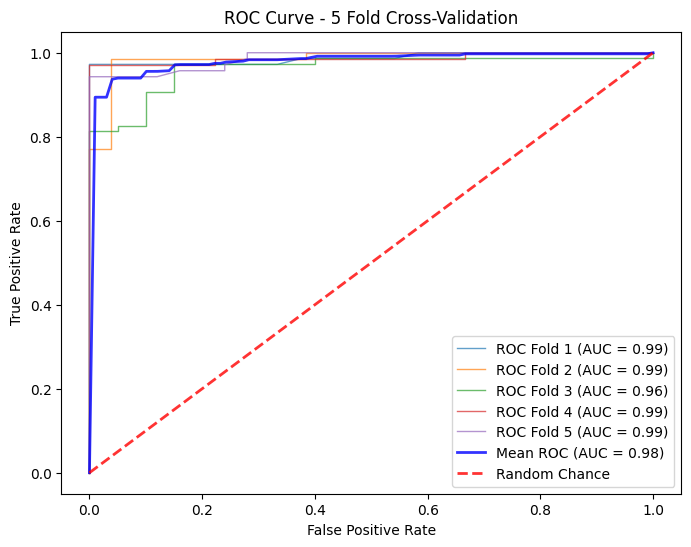

In [119]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [120]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93        21
           1       1.00      0.96      0.98        75

    accuracy                           0.97        96
   macro avg       0.94      0.98      0.96        96
weighted avg       0.97      0.97      0.97        96



In [121]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.25 ± 0.01
SCORE_TIME - Mean: 0.08 ± 0.00
TEST_ACCURACY - Mean: 0.72 ± 0.03
TEST_F1 - Mean: 0.84 ± 0.02
TEST_ROC_AUC - Mean: 0.49 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.76 ± 0.04
TEST_PRECISION - Mean: 0.74 ± 0.03
TEST_RECALL - Mean: 0.96 ± 0.02


In [122]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7649 ± 0.04


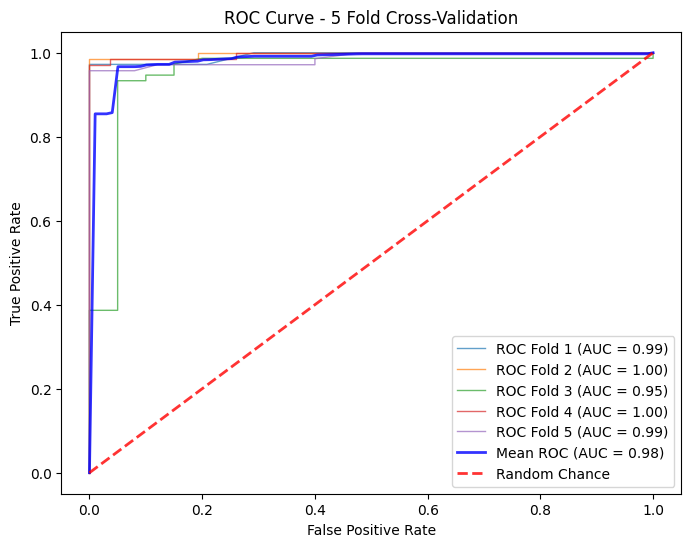

In [123]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [124]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.97      0.99      0.98        74

    accuracy                           0.97        96
   macro avg       0.96      0.95      0.96        96
weighted avg       0.97      0.97      0.97        96



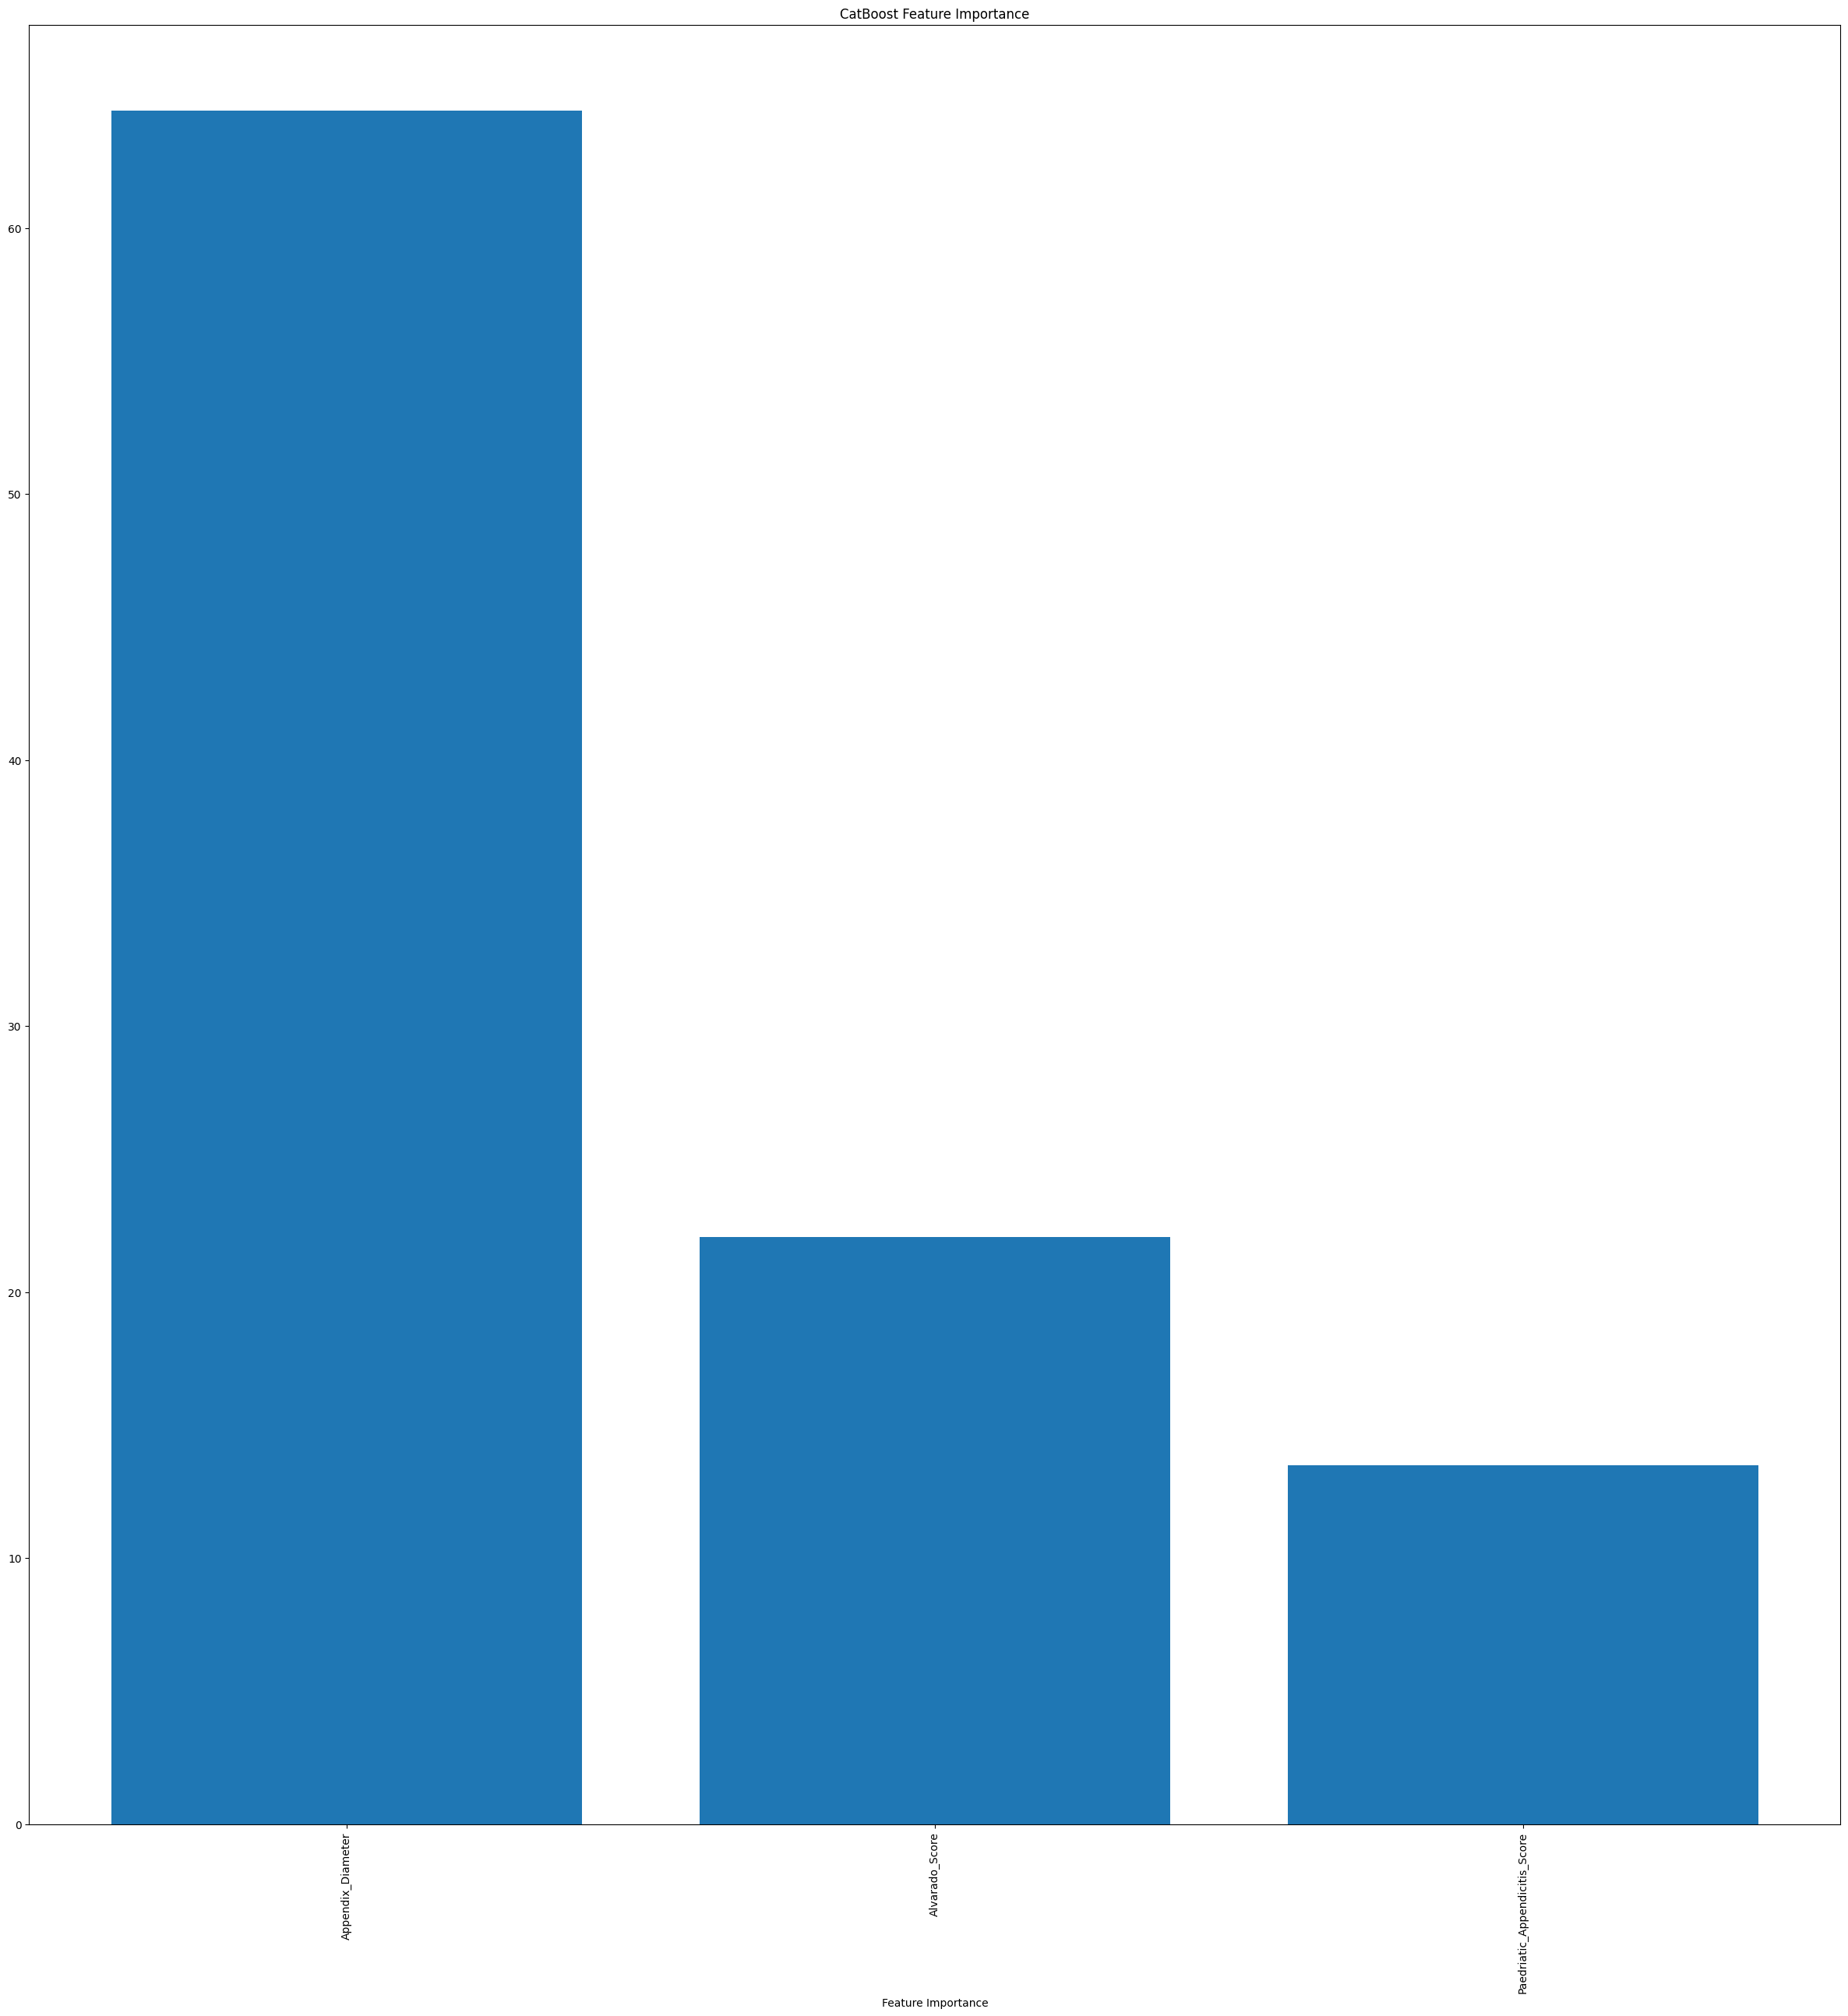

In [125]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = X.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [126]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6905162	total: 3.37ms	remaining: 5.05s
1:	learn: 0.6878893	total: 7.49ms	remaining: 5.61s
2:	learn: 0.6852649	total: 11.3ms	remaining: 5.64s
3:	learn: 0.6824591	total: 15.1ms	remaining: 5.63s
4:	learn: 0.6800372	total: 18.6ms	remaining: 5.56s
5:	learn: 0.6773672	total: 21.6ms	remaining: 5.38s
6:	learn: 0.6748870	total: 25.3ms	remaining: 5.39s
7:	learn: 0.6725575	total: 27.7ms	remaining: 5.17s
8:	learn: 0.6701610	total: 31ms	remaining: 5.13s
9:	learn: 0.6674381	total: 34.6ms	remaining: 5.16s
10:	learn: 0.6650314	total: 38.8ms	remaining: 5.25s
11:	learn: 0.6624048	total: 42.3ms	remaining: 5.25s
12:	learn: 0.6602870	total: 46.6ms	remaining: 5.33s
13:	learn: 0.6579876	total: 48.9ms	remaining: 5.19s
14:	learn: 0.6556865	total: 52.2ms	remaining: 5.17s
15:	learn: 0.6538210	total: 54.1ms	remaining: 5.02s
16:	learn: 0.6515307	total: 57.7ms	remaining: 5.04s
17:	learn: 0.6494745	total: 61ms	remaining: 5.02s
18:	learn: 0.6473428	total: 63.4ms	remaining: 4.94s
19:	learn: 0.6453861	total

198:	learn: 0.5325031	total: 744ms	remaining: 4.86s
199:	learn: 0.5322666	total: 748ms	remaining: 4.86s
200:	learn: 0.5319874	total: 752ms	remaining: 4.86s
201:	learn: 0.5318721	total: 757ms	remaining: 4.87s
202:	learn: 0.5316990	total: 762ms	remaining: 4.87s
203:	learn: 0.5314481	total: 766ms	remaining: 4.87s
204:	learn: 0.5309614	total: 770ms	remaining: 4.86s
205:	learn: 0.5307257	total: 775ms	remaining: 4.87s
206:	learn: 0.5304865	total: 779ms	remaining: 4.86s
207:	learn: 0.5301546	total: 783ms	remaining: 4.86s
208:	learn: 0.5300064	total: 787ms	remaining: 4.86s
209:	learn: 0.5298567	total: 791ms	remaining: 4.86s
210:	learn: 0.5296459	total: 796ms	remaining: 4.86s
211:	learn: 0.5294408	total: 798ms	remaining: 4.85s
212:	learn: 0.5293266	total: 803ms	remaining: 4.85s
213:	learn: 0.5289908	total: 807ms	remaining: 4.85s
214:	learn: 0.5289620	total: 810ms	remaining: 4.84s
215:	learn: 0.5287008	total: 813ms	remaining: 4.83s
216:	learn: 0.5284811	total: 817ms	remaining: 4.83s
217:	learn: 

388:	learn: 0.5014385	total: 1.5s	remaining: 4.29s
389:	learn: 0.5012987	total: 1.51s	remaining: 4.29s
390:	learn: 0.5012682	total: 1.51s	remaining: 4.28s
391:	learn: 0.5010553	total: 1.51s	remaining: 4.28s
392:	learn: 0.5010021	total: 1.52s	remaining: 4.28s
393:	learn: 0.5007223	total: 1.52s	remaining: 4.27s
394:	learn: 0.5004946	total: 1.53s	remaining: 4.27s
395:	learn: 0.5003817	total: 1.53s	remaining: 4.27s
396:	learn: 0.5002754	total: 1.54s	remaining: 4.27s
397:	learn: 0.5001711	total: 1.54s	remaining: 4.27s
398:	learn: 0.4997006	total: 1.55s	remaining: 4.27s
399:	learn: 0.4996147	total: 1.55s	remaining: 4.26s
400:	learn: 0.4995178	total: 1.55s	remaining: 4.26s
401:	learn: 0.4993307	total: 1.56s	remaining: 4.26s
402:	learn: 0.4991184	total: 1.56s	remaining: 4.26s
403:	learn: 0.4989345	total: 1.57s	remaining: 4.25s
404:	learn: 0.4988810	total: 1.57s	remaining: 4.25s
405:	learn: 0.4986327	total: 1.58s	remaining: 4.25s
406:	learn: 0.4985976	total: 1.58s	remaining: 4.24s
407:	learn: 0

564:	learn: 0.4789052	total: 2.28s	remaining: 3.77s
565:	learn: 0.4788777	total: 2.28s	remaining: 3.77s
566:	learn: 0.4788239	total: 2.29s	remaining: 3.76s
567:	learn: 0.4786092	total: 2.29s	remaining: 3.76s
568:	learn: 0.4786056	total: 2.29s	remaining: 3.75s
569:	learn: 0.4784952	total: 2.3s	remaining: 3.75s
570:	learn: 0.4784426	total: 2.3s	remaining: 3.75s
571:	learn: 0.4783395	total: 2.31s	remaining: 3.74s
572:	learn: 0.4781442	total: 2.31s	remaining: 3.74s
573:	learn: 0.4780909	total: 2.31s	remaining: 3.73s
574:	learn: 0.4780436	total: 2.32s	remaining: 3.73s
575:	learn: 0.4779565	total: 2.32s	remaining: 3.73s
576:	learn: 0.4778793	total: 2.33s	remaining: 3.72s
577:	learn: 0.4778556	total: 2.33s	remaining: 3.72s
578:	learn: 0.4777769	total: 2.33s	remaining: 3.71s
579:	learn: 0.4776855	total: 2.34s	remaining: 3.71s
580:	learn: 0.4776007	total: 2.34s	remaining: 3.71s
581:	learn: 0.4774779	total: 2.35s	remaining: 3.7s
582:	learn: 0.4774327	total: 2.35s	remaining: 3.7s
583:	learn: 0.47

735:	learn: 0.4567758	total: 3.04s	remaining: 3.16s
736:	learn: 0.4566191	total: 3.05s	remaining: 3.16s
737:	learn: 0.4564252	total: 3.05s	remaining: 3.15s
738:	learn: 0.4563149	total: 3.06s	remaining: 3.15s
739:	learn: 0.4562017	total: 3.06s	remaining: 3.15s
740:	learn: 0.4559874	total: 3.07s	remaining: 3.14s
741:	learn: 0.4558956	total: 3.07s	remaining: 3.14s
742:	learn: 0.4557457	total: 3.08s	remaining: 3.13s
743:	learn: 0.4556958	total: 3.08s	remaining: 3.13s
744:	learn: 0.4556264	total: 3.08s	remaining: 3.13s
745:	learn: 0.4554828	total: 3.09s	remaining: 3.12s
746:	learn: 0.4551412	total: 3.09s	remaining: 3.12s
747:	learn: 0.4549978	total: 3.1s	remaining: 3.11s
748:	learn: 0.4547150	total: 3.1s	remaining: 3.11s
749:	learn: 0.4546724	total: 3.1s	remaining: 3.1s
750:	learn: 0.4545522	total: 3.11s	remaining: 3.1s
751:	learn: 0.4544864	total: 3.11s	remaining: 3.1s
752:	learn: 0.4543683	total: 3.12s	remaining: 3.09s
753:	learn: 0.4538985	total: 3.12s	remaining: 3.09s
754:	learn: 0.4536

...

750:	learn: 0.4460866	total: 2.87s	remaining: 2.86s
751:	learn: 0.4459389	total: 2.88s	remaining: 2.86s
752:	learn: 0.4457080	total: 2.88s	remaining: 2.86s
753:	learn: 0.4455765	total: 2.88s	remaining: 2.85s
754:	learn: 0.4453562	total: 2.89s	remaining: 2.85s
755:	learn: 0.4451085	total: 2.89s	remaining: 2.85s
756:	learn: 0.4450682	total: 2.9s	remaining: 2.84s
757:	learn: 0.4449725	total: 2.9s	remaining: 2.84s
758:	learn: 0.4447653	total: 2.91s	remaining: 2.84s
759:	learn: 0.4447129	total: 2.91s	remaining: 2.83s
760:	learn: 0.4445019	total: 2.91s	remaining: 2.83s
761:	learn: 0.4442448	total: 2.92s	remaining: 2.83s
762:	learn: 0.4442158	total: 2.92s	remaining: 2.82s
763:	learn: 0.4441625	total: 2.93s	remaining: 2.82s
764:	learn: 0.4441187	total: 2.93s	remaining: 2.81s
765:	learn: 0.4438364	total: 2.93s	remaining: 2.81s
766:	learn: 0.4437618	total: 2.94s	remaining: 2.81s
767:	learn: 0.4436161	total: 2.94s	remaining: 2.81s
768:	learn: 0.4435072	total: 2.95s	remaining: 2.8s
769:	learn: 0.4

925:	learn: 0.4200060	total: 3.63s	remaining: 2.25s
926:	learn: 0.4199082	total: 3.63s	remaining: 2.25s
927:	learn: 0.4196766	total: 3.63s	remaining: 2.24s
928:	learn: 0.4194773	total: 3.64s	remaining: 2.24s
929:	learn: 0.4193497	total: 3.64s	remaining: 2.23s
930:	learn: 0.4192627	total: 3.65s	remaining: 2.23s
931:	learn: 0.4192088	total: 3.65s	remaining: 2.23s
932:	learn: 0.4190146	total: 3.66s	remaining: 2.22s
933:	learn: 0.4189064	total: 3.66s	remaining: 2.22s
934:	learn: 0.4187876	total: 3.66s	remaining: 2.21s
935:	learn: 0.4186399	total: 3.67s	remaining: 2.21s
936:	learn: 0.4185365	total: 3.67s	remaining: 2.21s
937:	learn: 0.4183030	total: 3.68s	remaining: 2.2s
938:	learn: 0.4182242	total: 3.68s	remaining: 2.2s
939:	learn: 0.4181565	total: 3.69s	remaining: 2.2s
940:	learn: 0.4180052	total: 3.69s	remaining: 2.19s
941:	learn: 0.4178263	total: 3.69s	remaining: 2.19s
942:	learn: 0.4177101	total: 3.7s	remaining: 2.18s
943:	learn: 0.4175658	total: 3.7s	remaining: 2.18s
944:	learn: 0.417

1115:	learn: 0.3956397	total: 4.39s	remaining: 1.51s
1116:	learn: 0.3955639	total: 4.4s	remaining: 1.51s
1117:	learn: 0.3953258	total: 4.4s	remaining: 1.5s
1118:	learn: 0.3951288	total: 4.41s	remaining: 1.5s
1119:	learn: 0.3949658	total: 4.41s	remaining: 1.5s
1120:	learn: 0.3948679	total: 4.41s	remaining: 1.49s
1121:	learn: 0.3948016	total: 4.42s	remaining: 1.49s
1122:	learn: 0.3945722	total: 4.42s	remaining: 1.49s
1123:	learn: 0.3945269	total: 4.43s	remaining: 1.48s
1124:	learn: 0.3944281	total: 4.43s	remaining: 1.48s
1125:	learn: 0.3943298	total: 4.44s	remaining: 1.47s
1126:	learn: 0.3942346	total: 4.44s	remaining: 1.47s
1127:	learn: 0.3942009	total: 4.45s	remaining: 1.47s
1128:	learn: 0.3940156	total: 4.45s	remaining: 1.46s
1129:	learn: 0.3939606	total: 4.45s	remaining: 1.46s
1130:	learn: 0.3938477	total: 4.46s	remaining: 1.45s
1131:	learn: 0.3938317	total: 4.46s	remaining: 1.45s
1132:	learn: 0.3938047	total: 4.46s	remaining: 1.45s
1133:	learn: 0.3937205	total: 4.47s	remaining: 1.44

1300:	learn: 0.3754794	total: 5.16s	remaining: 789ms
1301:	learn: 0.3753526	total: 5.17s	remaining: 786ms
1302:	learn: 0.3752551	total: 5.17s	remaining: 781ms
1303:	learn: 0.3751785	total: 5.17s	remaining: 777ms
1304:	learn: 0.3749903	total: 5.18s	remaining: 773ms
1305:	learn: 0.3749644	total: 5.18s	remaining: 770ms
1306:	learn: 0.3748869	total: 5.18s	remaining: 766ms
1307:	learn: 0.3748398	total: 5.19s	remaining: 762ms
1308:	learn: 0.3747464	total: 5.19s	remaining: 758ms
1309:	learn: 0.3747044	total: 5.2s	remaining: 754ms
1310:	learn: 0.3746694	total: 5.2s	remaining: 750ms
1311:	learn: 0.3746492	total: 5.2s	remaining: 746ms
1312:	learn: 0.3746108	total: 5.21s	remaining: 742ms
1313:	learn: 0.3744642	total: 5.21s	remaining: 738ms
1314:	learn: 0.3742881	total: 5.22s	remaining: 734ms
1315:	learn: 0.3742094	total: 5.22s	remaining: 730ms
1316:	learn: 0.3739930	total: 5.22s	remaining: 726ms
1317:	learn: 0.3739271	total: 5.23s	remaining: 722ms
1318:	learn: 0.3738918	total: 5.23s	remaining: 71

1480:	learn: 0.3588983	total: 5.92s	remaining: 75.9ms
1481:	learn: 0.3587926	total: 5.92s	remaining: 72ms
1482:	learn: 0.3586377	total: 5.93s	remaining: 68ms
1483:	learn: 0.3585764	total: 5.93s	remaining: 64ms
1484:	learn: 0.3584815	total: 5.94s	remaining: 60ms
1485:	learn: 0.3584404	total: 5.95s	remaining: 56ms
1486:	learn: 0.3583037	total: 5.95s	remaining: 52ms
1487:	learn: 0.3581182	total: 5.95s	remaining: 48ms
1488:	learn: 0.3579914	total: 5.96s	remaining: 44ms
1489:	learn: 0.3579104	total: 5.96s	remaining: 40ms
1490:	learn: 0.3577567	total: 5.96s	remaining: 36ms
1491:	learn: 0.3576794	total: 5.97s	remaining: 32ms
1492:	learn: 0.3574589	total: 5.97s	remaining: 28ms
1493:	learn: 0.3573659	total: 5.98s	remaining: 24ms
1494:	learn: 0.3573410	total: 5.98s	remaining: 20ms
1495:	learn: 0.3572552	total: 5.99s	remaining: 16ms
1496:	learn: 0.3571705	total: 5.99s	remaining: 12ms
1497:	learn: 0.3570521	total: 6s	remaining: 8.01ms
1498:	learn: 0.3569821	total: 6s	remaining: 4ms
1499:	learn: 0.

In [127]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

0:	learn: 0.6905162	total: 2.94ms	remaining: 4.4s
1:	learn: 0.6878893	total: 8.96ms	remaining: 6.71s
2:	learn: 0.6852649	total: 13ms	remaining: 6.5s
3:	learn: 0.6824591	total: 17.9ms	remaining: 6.69s
4:	learn: 0.6800372	total: 22.8ms	remaining: 6.81s
5:	learn: 0.6773672	total: 26.6ms	remaining: 6.61s
6:	learn: 0.6748870	total: 30.4ms	remaining: 6.49s
7:	learn: 0.6725575	total: 34.4ms	remaining: 6.41s
8:	learn: 0.6701610	total: 40.2ms	remaining: 6.66s
9:	learn: 0.6674381	total: 44.1ms	remaining: 6.57s
10:	learn: 0.6650314	total: 48.5ms	remaining: 6.57s
11:	learn: 0.6624048	total: 53.4ms	remaining: 6.62s
12:	learn: 0.6602870	total: 57.8ms	remaining: 6.62s
13:	learn: 0.6579876	total: 61.6ms	remaining: 6.54s
14:	learn: 0.6556865	total: 65.4ms	remaining: 6.47s
15:	learn: 0.6538210	total: 69.6ms	remaining: 6.45s
16:	learn: 0.6515307	total: 73.2ms	remaining: 6.39s
17:	learn: 0.6494745	total: 76.7ms	remaining: 6.31s
18:	learn: 0.6473428	total: 81.5ms	remaining: 6.35s
19:	learn: 0.6453861	total

187:	learn: 0.5352938	total: 764ms	remaining: 5.33s
188:	learn: 0.5351011	total: 768ms	remaining: 5.32s
189:	learn: 0.5349499	total: 772ms	remaining: 5.32s
190:	learn: 0.5347562	total: 776ms	remaining: 5.32s
191:	learn: 0.5342706	total: 779ms	remaining: 5.31s
192:	learn: 0.5340470	total: 781ms	remaining: 5.29s
193:	learn: 0.5338666	total: 785ms	remaining: 5.28s
194:	learn: 0.5333872	total: 789ms	remaining: 5.28s
195:	learn: 0.5331932	total: 792ms	remaining: 5.27s
196:	learn: 0.5329909	total: 797ms	remaining: 5.27s
197:	learn: 0.5327727	total: 801ms	remaining: 5.26s
198:	learn: 0.5325031	total: 804ms	remaining: 5.26s
199:	learn: 0.5322666	total: 808ms	remaining: 5.25s
200:	learn: 0.5319874	total: 811ms	remaining: 5.24s
201:	learn: 0.5318721	total: 814ms	remaining: 5.23s
202:	learn: 0.5316990	total: 819ms	remaining: 5.23s
203:	learn: 0.5314481	total: 821ms	remaining: 5.21s
204:	learn: 0.5309614	total: 824ms	remaining: 5.21s
205:	learn: 0.5307257	total: 828ms	remaining: 5.2s
206:	learn: 0

348:	learn: 0.5068096	total: 1.33s	remaining: 4.41s
349:	learn: 0.5066158	total: 1.34s	remaining: 4.4s
350:	learn: 0.5064569	total: 1.34s	remaining: 4.4s
351:	learn: 0.5063893	total: 1.35s	remaining: 4.4s
352:	learn: 0.5063367	total: 1.35s	remaining: 4.39s
353:	learn: 0.5061208	total: 1.36s	remaining: 4.39s
354:	learn: 0.5059769	total: 1.36s	remaining: 4.39s
355:	learn: 0.5057712	total: 1.36s	remaining: 4.38s
356:	learn: 0.5057119	total: 1.37s	remaining: 4.37s
357:	learn: 0.5053835	total: 1.37s	remaining: 4.37s
358:	learn: 0.5052752	total: 1.37s	remaining: 4.36s
359:	learn: 0.5052073	total: 1.38s	remaining: 4.36s
360:	learn: 0.5051846	total: 1.38s	remaining: 4.35s
361:	learn: 0.5050824	total: 1.38s	remaining: 4.34s
362:	learn: 0.5048992	total: 1.39s	remaining: 4.34s
363:	learn: 0.5047860	total: 1.39s	remaining: 4.34s
364:	learn: 0.5046502	total: 1.39s	remaining: 4.33s
365:	learn: 0.5046048	total: 1.4s	remaining: 4.32s
366:	learn: 0.5046035	total: 1.4s	remaining: 4.32s
367:	learn: 0.504

539:	learn: 0.4828955	total: 2.1s	remaining: 3.73s
540:	learn: 0.4827346	total: 2.1s	remaining: 3.72s
541:	learn: 0.4824711	total: 2.11s	remaining: 3.72s
542:	learn: 0.4821829	total: 2.11s	remaining: 3.72s
543:	learn: 0.4819093	total: 2.11s	remaining: 3.72s
544:	learn: 0.4818126	total: 2.12s	remaining: 3.71s
545:	learn: 0.4817493	total: 2.12s	remaining: 3.71s
546:	learn: 0.4816468	total: 2.13s	remaining: 3.71s
547:	learn: 0.4815628	total: 2.13s	remaining: 3.7s
548:	learn: 0.4815208	total: 2.13s	remaining: 3.7s
549:	learn: 0.4811630	total: 2.14s	remaining: 3.69s
550:	learn: 0.4810642	total: 2.14s	remaining: 3.69s
551:	learn: 0.4808252	total: 2.15s	remaining: 3.69s
552:	learn: 0.4806566	total: 2.15s	remaining: 3.68s
553:	learn: 0.4804613	total: 2.15s	remaining: 3.68s
554:	learn: 0.4803879	total: 2.16s	remaining: 3.67s
555:	learn: 0.4801303	total: 2.16s	remaining: 3.67s
556:	learn: 0.4799544	total: 2.17s	remaining: 3.67s
557:	learn: 0.4798099	total: 2.17s	remaining: 3.67s
558:	learn: 0.47

726:	learn: 0.4579810	total: 2.86s	remaining: 3.04s
727:	learn: 0.4579008	total: 2.87s	remaining: 3.04s
728:	learn: 0.4577266	total: 2.87s	remaining: 3.03s
729:	learn: 0.4575871	total: 2.87s	remaining: 3.03s
730:	learn: 0.4575016	total: 2.88s	remaining: 3.03s
731:	learn: 0.4573998	total: 2.88s	remaining: 3.02s
732:	learn: 0.4573293	total: 2.88s	remaining: 3.02s
733:	learn: 0.4569302	total: 2.89s	remaining: 3.01s
734:	learn: 0.4568570	total: 2.89s	remaining: 3.01s
735:	learn: 0.4567758	total: 2.9s	remaining: 3s
736:	learn: 0.4566191	total: 2.9s	remaining: 3s
737:	learn: 0.4564252	total: 2.9s	remaining: 3s
738:	learn: 0.4563149	total: 2.91s	remaining: 3s
739:	learn: 0.4562017	total: 2.91s	remaining: 2.99s
740:	learn: 0.4559874	total: 2.92s	remaining: 2.99s
741:	learn: 0.4558956	total: 2.92s	remaining: 2.98s
742:	learn: 0.4557457	total: 2.92s	remaining: 2.98s
743:	learn: 0.4556958	total: 2.93s	remaining: 2.98s
744:	learn: 0.4556264	total: 2.93s	remaining: 2.97s
745:	learn: 0.4554828	total

...

731:	learn: 0.4490060	total: 3.29s	remaining: 3.45s
732:	learn: 0.4487474	total: 3.29s	remaining: 3.45s
733:	learn: 0.4486140	total: 3.3s	remaining: 3.44s
734:	learn: 0.4484265	total: 3.3s	remaining: 3.44s
735:	learn: 0.4483767	total: 3.31s	remaining: 3.43s
736:	learn: 0.4482768	total: 3.31s	remaining: 3.43s
737:	learn: 0.4481185	total: 3.31s	remaining: 3.42s
738:	learn: 0.4477650	total: 3.32s	remaining: 3.42s
739:	learn: 0.4476460	total: 3.32s	remaining: 3.41s
740:	learn: 0.4474771	total: 3.33s	remaining: 3.41s
741:	learn: 0.4473177	total: 3.33s	remaining: 3.4s
742:	learn: 0.4470532	total: 3.34s	remaining: 3.4s
743:	learn: 0.4469112	total: 3.34s	remaining: 3.4s
744:	learn: 0.4468398	total: 3.35s	remaining: 3.39s
745:	learn: 0.4467088	total: 3.35s	remaining: 3.39s
746:	learn: 0.4465479	total: 3.35s	remaining: 3.38s
747:	learn: 0.4464660	total: 3.36s	remaining: 3.38s
748:	learn: 0.4462606	total: 3.36s	remaining: 3.37s
749:	learn: 0.4462290	total: 3.37s	remaining: 3.37s
750:	learn: 0.446

909:	learn: 0.4225704	total: 4.06s	remaining: 2.63s
910:	learn: 0.4223310	total: 4.07s	remaining: 2.63s
911:	learn: 0.4222649	total: 4.07s	remaining: 2.62s
912:	learn: 0.4221143	total: 4.07s	remaining: 2.62s
913:	learn: 0.4220059	total: 4.08s	remaining: 2.62s
914:	learn: 0.4218918	total: 4.08s	remaining: 2.61s
915:	learn: 0.4216498	total: 4.09s	remaining: 2.61s
916:	learn: 0.4214910	total: 4.09s	remaining: 2.6s
917:	learn: 0.4214068	total: 4.1s	remaining: 2.6s
918:	learn: 0.4213415	total: 4.1s	remaining: 2.59s
919:	learn: 0.4211606	total: 4.11s	remaining: 2.59s
920:	learn: 0.4208400	total: 4.11s	remaining: 2.58s
921:	learn: 0.4207329	total: 4.12s	remaining: 2.58s
922:	learn: 0.4205127	total: 4.12s	remaining: 2.58s
923:	learn: 0.4204411	total: 4.12s	remaining: 2.57s
924:	learn: 0.4202366	total: 4.13s	remaining: 2.57s
925:	learn: 0.4200060	total: 4.13s	remaining: 2.56s
926:	learn: 0.4199082	total: 4.14s	remaining: 2.56s
927:	learn: 0.4196766	total: 4.14s	remaining: 2.55s
928:	learn: 0.41

1079:	learn: 0.3999071	total: 4.82s	remaining: 1.88s
1080:	learn: 0.3998040	total: 4.83s	remaining: 1.87s
1081:	learn: 0.3997563	total: 4.83s	remaining: 1.87s
1082:	learn: 0.3996712	total: 4.84s	remaining: 1.86s
1083:	learn: 0.3996336	total: 4.84s	remaining: 1.86s
1084:	learn: 0.3994442	total: 4.85s	remaining: 1.85s
1085:	learn: 0.3994079	total: 4.85s	remaining: 1.85s
1086:	learn: 0.3993122	total: 4.86s	remaining: 1.85s
1087:	learn: 0.3992179	total: 4.86s	remaining: 1.84s
1088:	learn: 0.3991416	total: 4.87s	remaining: 1.84s
1089:	learn: 0.3990453	total: 4.87s	remaining: 1.83s
1090:	learn: 0.3988549	total: 4.88s	remaining: 1.83s
1091:	learn: 0.3986831	total: 4.88s	remaining: 1.82s
1092:	learn: 0.3985122	total: 4.89s	remaining: 1.82s
1093:	learn: 0.3983458	total: 4.89s	remaining: 1.81s
1094:	learn: 0.3982894	total: 4.9s	remaining: 1.81s
1095:	learn: 0.3981818	total: 4.9s	remaining: 1.81s
1096:	learn: 0.3980948	total: 4.91s	remaining: 1.8s
1097:	learn: 0.3979942	total: 4.91s	remaining: 1.

1250:	learn: 0.3806907	total: 5.59s	remaining: 1.11s
1251:	learn: 0.3805615	total: 5.6s	remaining: 1.11s
1252:	learn: 0.3804300	total: 5.6s	remaining: 1.1s
1253:	learn: 0.3803516	total: 5.61s	remaining: 1.1s
1254:	learn: 0.3803234	total: 5.61s	remaining: 1.09s
1255:	learn: 0.3802997	total: 5.62s	remaining: 1.09s
1256:	learn: 0.3801415	total: 5.62s	remaining: 1.09s
1257:	learn: 0.3801014	total: 5.63s	remaining: 1.08s
1258:	learn: 0.3800150	total: 5.63s	remaining: 1.08s
1259:	learn: 0.3799473	total: 5.63s	remaining: 1.07s
1260:	learn: 0.3798640	total: 5.64s	remaining: 1.07s
1261:	learn: 0.3798282	total: 5.64s	remaining: 1.06s
1262:	learn: 0.3797286	total: 5.65s	remaining: 1.06s
1263:	learn: 0.3796421	total: 5.65s	remaining: 1.05s
1264:	learn: 0.3795462	total: 5.66s	remaining: 1.05s
1265:	learn: 0.3795217	total: 5.66s	remaining: 1.05s
1266:	learn: 0.3794250	total: 5.66s	remaining: 1.04s
1267:	learn: 0.3793576	total: 5.67s	remaining: 1.04s
1268:	learn: 0.3793333	total: 5.67s	remaining: 1.0

1418:	learn: 0.3648149	total: 6.37s	remaining: 363ms
1419:	learn: 0.3647555	total: 6.37s	remaining: 359ms
1420:	learn: 0.3646963	total: 6.38s	remaining: 354ms
1421:	learn: 0.3646250	total: 6.38s	remaining: 350ms
1422:	learn: 0.3645484	total: 6.38s	remaining: 346ms
1423:	learn: 0.3644731	total: 6.39s	remaining: 341ms
1424:	learn: 0.3643080	total: 6.39s	remaining: 337ms
1425:	learn: 0.3640237	total: 6.4s	remaining: 332ms
1426:	learn: 0.3639657	total: 6.4s	remaining: 328ms
1427:	learn: 0.3638967	total: 6.41s	remaining: 323ms
1428:	learn: 0.3637806	total: 6.41s	remaining: 319ms
1429:	learn: 0.3637361	total: 6.41s	remaining: 314ms
1430:	learn: 0.3637029	total: 6.42s	remaining: 310ms
1431:	learn: 0.3635670	total: 6.42s	remaining: 305ms
1432:	learn: 0.3635174	total: 6.43s	remaining: 301ms
1433:	learn: 0.3633913	total: 6.43s	remaining: 296ms
1434:	learn: 0.3632677	total: 6.44s	remaining: 292ms
1435:	learn: 0.3631750	total: 6.44s	remaining: 287ms
1436:	learn: 0.3631312	total: 6.45s	remaining: 2

In [128]:
# calculating auc for 5 folds : lagaing dimaaaaag

from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
# scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)
score = cross_val_score(model,X,y,scoring = 'roc_auc')

print(score)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6747506	total: 4.92ms	remaining: 7.37s
1:	learn: 0.6548714	total: 12.7ms	remaining: 9.53s
2:	learn: 0.6389628	total: 18ms	remaining: 8.96s
3:	learn: 0.6241694	total: 24.4ms	remaining: 9.13s
4:	learn: 0.6132357	total: 30ms	remaining: 8.96s
5:	learn: 0.5993871	total: 34.9ms	remaining: 8.69s
6:	learn: 0.5902465	total: 39.5ms	remaining: 8.41s
7:	learn: 0.5719007	total: 44.5ms	remaining: 8.29s
8:	learn: 0.5610427	total: 49.8ms	remaining: 8.25s
9:	learn: 0.5491644	total: 54.8ms	remaining: 8.17s
10:	learn: 0.5331578	total: 59.9ms	remaining: 8.11s
11:	learn: 0.5241950	total: 64.5ms	remaining: 8s
12:	learn: 0.5086450	total: 71.2ms	remaining: 8.14s
13:	learn: 0.4982146	total: 76ms	remaining: 8.06s
14:	learn: 0.4842959	total: 81.3ms	remaining: 8.05s
15:	learn: 0.4734750	total: 88ms	remaining: 8.16s
16:	learn: 0.4630532	total: 93.5ms	remaining: 8.15s
17:	learn: 0.4533915	total: 99ms	remaining: 8.15s
18:	learn: 0.4419503	total: 105ms	remaining: 8.2s
19:	learn: 0.4328299	total: 110ms	rem

173:	learn: 0.1023546	total: 755ms	remaining: 5.75s
174:	learn: 0.1020090	total: 761ms	remaining: 5.76s
175:	learn: 0.1017369	total: 766ms	remaining: 5.76s
176:	learn: 0.1014418	total: 771ms	remaining: 5.76s
177:	learn: 0.1011630	total: 775ms	remaining: 5.75s
178:	learn: 0.1010240	total: 779ms	remaining: 5.75s
179:	learn: 0.1008618	total: 784ms	remaining: 5.75s
180:	learn: 0.1005001	total: 788ms	remaining: 5.74s
181:	learn: 0.1000816	total: 791ms	remaining: 5.73s
182:	learn: 0.0996512	total: 797ms	remaining: 5.73s
183:	learn: 0.0994192	total: 803ms	remaining: 5.74s
184:	learn: 0.0990231	total: 808ms	remaining: 5.74s
185:	learn: 0.0987951	total: 812ms	remaining: 5.73s
186:	learn: 0.0983636	total: 816ms	remaining: 5.73s
187:	learn: 0.0981680	total: 820ms	remaining: 5.72s
188:	learn: 0.0980276	total: 824ms	remaining: 5.72s
189:	learn: 0.0977833	total: 828ms	remaining: 5.71s
190:	learn: 0.0973273	total: 832ms	remaining: 5.7s
191:	learn: 0.0971395	total: 836ms	remaining: 5.7s
192:	learn: 0.

353:	learn: 0.0732317	total: 1.48s	remaining: 4.79s
354:	learn: 0.0731883	total: 1.49s	remaining: 4.79s
355:	learn: 0.0731165	total: 1.49s	remaining: 4.79s
356:	learn: 0.0730562	total: 1.5s	remaining: 4.79s
357:	learn: 0.0729332	total: 1.5s	remaining: 4.78s
358:	learn: 0.0727793	total: 1.5s	remaining: 4.78s
359:	learn: 0.0725866	total: 1.51s	remaining: 4.78s
360:	learn: 0.0724695	total: 1.51s	remaining: 4.77s
361:	learn: 0.0723717	total: 1.52s	remaining: 4.77s
362:	learn: 0.0723697	total: 1.52s	remaining: 4.76s
363:	learn: 0.0722032	total: 1.52s	remaining: 4.76s
364:	learn: 0.0721513	total: 1.53s	remaining: 4.76s
365:	learn: 0.0720894	total: 1.53s	remaining: 4.75s
366:	learn: 0.0719635	total: 1.54s	remaining: 4.75s
367:	learn: 0.0718546	total: 1.54s	remaining: 4.75s
368:	learn: 0.0717754	total: 1.55s	remaining: 4.74s
369:	learn: 0.0716429	total: 1.55s	remaining: 4.74s
370:	learn: 0.0716314	total: 1.55s	remaining: 4.73s
371:	learn: 0.0715587	total: 1.56s	remaining: 4.73s
372:	learn: 0.0

525:	learn: 0.0600716	total: 2.25s	remaining: 4.16s
526:	learn: 0.0600505	total: 2.25s	remaining: 4.16s
527:	learn: 0.0599361	total: 2.26s	remaining: 4.15s
528:	learn: 0.0598782	total: 2.26s	remaining: 4.15s
529:	learn: 0.0598364	total: 2.27s	remaining: 4.15s
530:	learn: 0.0598101	total: 2.27s	remaining: 4.14s
531:	learn: 0.0597593	total: 2.27s	remaining: 4.14s
532:	learn: 0.0597211	total: 2.28s	remaining: 4.13s
533:	learn: 0.0596927	total: 2.28s	remaining: 4.13s
534:	learn: 0.0596261	total: 2.29s	remaining: 4.13s
535:	learn: 0.0595296	total: 2.29s	remaining: 4.12s
536:	learn: 0.0594912	total: 2.29s	remaining: 4.12s
537:	learn: 0.0594389	total: 2.3s	remaining: 4.11s
538:	learn: 0.0593440	total: 2.3s	remaining: 4.11s
539:	learn: 0.0592988	total: 2.31s	remaining: 4.11s
540:	learn: 0.0592454	total: 2.31s	remaining: 4.1s
541:	learn: 0.0592078	total: 2.32s	remaining: 4.09s
542:	learn: 0.0591998	total: 2.32s	remaining: 4.09s
543:	learn: 0.0591699	total: 2.33s	remaining: 4.09s
544:	learn: 0.0

701:	learn: 0.0508613	total: 3.04s	remaining: 3.45s
702:	learn: 0.0508164	total: 3.04s	remaining: 3.45s
703:	learn: 0.0507856	total: 3.04s	remaining: 3.44s
704:	learn: 0.0507257	total: 3.05s	remaining: 3.44s
705:	learn: 0.0506999	total: 3.05s	remaining: 3.43s
706:	learn: 0.0506281	total: 3.06s	remaining: 3.43s
707:	learn: 0.0505860	total: 3.06s	remaining: 3.42s
708:	learn: 0.0505195	total: 3.06s	remaining: 3.42s
709:	learn: 0.0504375	total: 3.07s	remaining: 3.42s
710:	learn: 0.0503840	total: 3.07s	remaining: 3.41s
711:	learn: 0.0503401	total: 3.08s	remaining: 3.41s
712:	learn: 0.0502747	total: 3.08s	remaining: 3.4s
713:	learn: 0.0501810	total: 3.09s	remaining: 3.4s
714:	learn: 0.0500995	total: 3.09s	remaining: 3.39s
715:	learn: 0.0500680	total: 3.09s	remaining: 3.39s
716:	learn: 0.0500262	total: 3.1s	remaining: 3.38s
717:	learn: 0.0499254	total: 3.1s	remaining: 3.38s
718:	learn: 0.0498813	total: 3.11s	remaining: 3.38s
719:	learn: 0.0498066	total: 3.11s	remaining: 3.37s
720:	learn: 0.04

...

682:	learn: 0.0421553	total: 3.06s	remaining: 3.66s
683:	learn: 0.0421267	total: 3.06s	remaining: 3.65s
684:	learn: 0.0420286	total: 3.07s	remaining: 3.65s
685:	learn: 0.0419806	total: 3.08s	remaining: 3.65s
686:	learn: 0.0419013	total: 3.08s	remaining: 3.65s
687:	learn: 0.0418857	total: 3.08s	remaining: 3.64s
688:	learn: 0.0418248	total: 3.09s	remaining: 3.64s
689:	learn: 0.0417790	total: 3.09s	remaining: 3.63s
690:	learn: 0.0417340	total: 3.1s	remaining: 3.63s
691:	learn: 0.0416948	total: 3.1s	remaining: 3.62s
692:	learn: 0.0416404	total: 3.11s	remaining: 3.62s
693:	learn: 0.0415797	total: 3.11s	remaining: 3.61s
694:	learn: 0.0415661	total: 3.11s	remaining: 3.61s
695:	learn: 0.0415438	total: 3.12s	remaining: 3.6s
696:	learn: 0.0415056	total: 3.12s	remaining: 3.6s
697:	learn: 0.0414556	total: 3.13s	remaining: 3.59s
698:	learn: 0.0414116	total: 3.13s	remaining: 3.59s
699:	learn: 0.0413962	total: 3.13s	remaining: 3.58s
700:	learn: 0.0413640	total: 3.14s	remaining: 3.58s
701:	learn: 0.04

866:	learn: 0.0347375	total: 3.83s	remaining: 2.8s
867:	learn: 0.0347114	total: 3.84s	remaining: 2.79s
868:	learn: 0.0346638	total: 3.84s	remaining: 2.79s
869:	learn: 0.0346341	total: 3.85s	remaining: 2.79s
870:	learn: 0.0346064	total: 3.85s	remaining: 2.78s
871:	learn: 0.0345840	total: 3.85s	remaining: 2.78s
872:	learn: 0.0345372	total: 3.86s	remaining: 2.77s
873:	learn: 0.0345082	total: 3.86s	remaining: 2.77s
874:	learn: 0.0344799	total: 3.87s	remaining: 2.76s
875:	learn: 0.0344467	total: 3.87s	remaining: 2.76s
876:	learn: 0.0344140	total: 3.88s	remaining: 2.75s
877:	learn: 0.0343852	total: 3.88s	remaining: 2.75s
878:	learn: 0.0343576	total: 3.89s	remaining: 2.75s
879:	learn: 0.0343361	total: 3.89s	remaining: 2.74s
880:	learn: 0.0343075	total: 3.9s	remaining: 2.74s
881:	learn: 0.0342994	total: 3.9s	remaining: 2.73s
882:	learn: 0.0342669	total: 3.9s	remaining: 2.73s
883:	learn: 0.0342313	total: 3.91s	remaining: 2.72s
884:	learn: 0.0342031	total: 3.91s	remaining: 2.72s
885:	learn: 0.03

1048:	learn: 0.0296855	total: 4.6s	remaining: 1.98s
1049:	learn: 0.0296694	total: 4.6s	remaining: 1.97s
1050:	learn: 0.0296515	total: 4.61s	remaining: 1.97s
1051:	learn: 0.0296281	total: 4.61s	remaining: 1.97s
1052:	learn: 0.0296001	total: 4.62s	remaining: 1.96s
1053:	learn: 0.0295629	total: 4.62s	remaining: 1.96s
1054:	learn: 0.0295307	total: 4.63s	remaining: 1.95s
1055:	learn: 0.0295103	total: 4.63s	remaining: 1.95s
1056:	learn: 0.0294929	total: 4.63s	remaining: 1.94s
1057:	learn: 0.0294755	total: 4.64s	remaining: 1.94s
1058:	learn: 0.0294521	total: 4.64s	remaining: 1.93s
1059:	learn: 0.0294291	total: 4.65s	remaining: 1.93s
1060:	learn: 0.0293924	total: 4.65s	remaining: 1.93s
1061:	learn: 0.0293753	total: 4.66s	remaining: 1.92s
1062:	learn: 0.0293585	total: 4.66s	remaining: 1.92s
1063:	learn: 0.0293428	total: 4.66s	remaining: 1.91s
1064:	learn: 0.0293201	total: 4.67s	remaining: 1.91s
1065:	learn: 0.0293033	total: 4.67s	remaining: 1.9s
1066:	learn: 0.0292760	total: 4.68s	remaining: 1.

1237:	learn: 0.0257963	total: 5.39s	remaining: 1.14s
1238:	learn: 0.0257865	total: 5.4s	remaining: 1.14s
1239:	learn: 0.0257740	total: 5.4s	remaining: 1.13s
1240:	learn: 0.0257547	total: 5.41s	remaining: 1.13s
1241:	learn: 0.0257380	total: 5.41s	remaining: 1.12s
1242:	learn: 0.0257284	total: 5.41s	remaining: 1.12s
1243:	learn: 0.0257093	total: 5.42s	remaining: 1.11s
1244:	learn: 0.0256860	total: 5.42s	remaining: 1.11s
1245:	learn: 0.0256638	total: 5.43s	remaining: 1.11s
1246:	learn: 0.0256542	total: 5.43s	remaining: 1.1s
1247:	learn: 0.0256449	total: 5.43s	remaining: 1.1s
1248:	learn: 0.0256318	total: 5.44s	remaining: 1.09s
1249:	learn: 0.0256225	total: 5.44s	remaining: 1.09s
1250:	learn: 0.0256089	total: 5.45s	remaining: 1.08s
1251:	learn: 0.0255859	total: 5.45s	remaining: 1.08s
1252:	learn: 0.0255736	total: 5.46s	remaining: 1.07s
1253:	learn: 0.0255508	total: 5.46s	remaining: 1.07s
1254:	learn: 0.0255290	total: 5.46s	remaining: 1.07s
1255:	learn: 0.0255074	total: 5.47s	remaining: 1.0

1420:	learn: 0.0233324	total: 6.16s	remaining: 342ms
1421:	learn: 0.0233220	total: 6.17s	remaining: 338ms
1422:	learn: 0.0233093	total: 6.17s	remaining: 334ms
1423:	learn: 0.0232940	total: 6.17s	remaining: 329ms
1424:	learn: 0.0232879	total: 6.18s	remaining: 325ms
1425:	learn: 0.0232820	total: 6.18s	remaining: 321ms
1426:	learn: 0.0232710	total: 6.19s	remaining: 316ms
1427:	learn: 0.0232586	total: 6.19s	remaining: 312ms
1428:	learn: 0.0232503	total: 6.19s	remaining: 308ms
1429:	learn: 0.0232366	total: 6.2s	remaining: 303ms
1430:	learn: 0.0232273	total: 6.2s	remaining: 299ms
1431:	learn: 0.0232215	total: 6.21s	remaining: 295ms
1432:	learn: 0.0232156	total: 6.21s	remaining: 290ms
1433:	learn: 0.0232022	total: 6.21s	remaining: 286ms
1434:	learn: 0.0231899	total: 6.22s	remaining: 282ms
1435:	learn: 0.0231747	total: 6.22s	remaining: 277ms
1436:	learn: 0.0231690	total: 6.23s	remaining: 273ms
1437:	learn: 0.0231581	total: 6.23s	remaining: 269ms
1438:	learn: 0.0231417	total: 6.23s	remaining: 2

0:	learn: 0.6746711	total: 4.46ms	remaining: 6.69s
1:	learn: 0.6597325	total: 8.83ms	remaining: 6.62s
2:	learn: 0.6426327	total: 14.2ms	remaining: 7.09s
3:	learn: 0.6282155	total: 17.9ms	remaining: 6.7s
4:	learn: 0.6179892	total: 22.4ms	remaining: 6.71s
5:	learn: 0.6011964	total: 26.1ms	remaining: 6.49s
6:	learn: 0.5925885	total: 29.9ms	remaining: 6.38s
7:	learn: 0.5738793	total: 33.8ms	remaining: 6.31s
8:	learn: 0.5632221	total: 37.6ms	remaining: 6.23s
9:	learn: 0.5507200	total: 40.9ms	remaining: 6.1s
10:	learn: 0.5386901	total: 45.5ms	remaining: 6.16s
11:	learn: 0.5301564	total: 49.2ms	remaining: 6.1s
12:	learn: 0.5163713	total: 53.7ms	remaining: 6.14s
13:	learn: 0.5033098	total: 57.8ms	remaining: 6.14s
14:	learn: 0.4911011	total: 61.4ms	remaining: 6.08s
15:	learn: 0.4816053	total: 65.2ms	remaining: 6.04s
16:	learn: 0.4720407	total: 69.8ms	remaining: 6.09s
17:	learn: 0.4634437	total: 73.8ms	remaining: 6.08s
18:	learn: 0.4521130	total: 77.9ms	remaining: 6.07s
19:	learn: 0.4425482	tota

189:	learn: 0.0918848	total: 769ms	remaining: 5.3s
190:	learn: 0.0917357	total: 773ms	remaining: 5.3s
191:	learn: 0.0914620	total: 778ms	remaining: 5.3s
192:	learn: 0.0911792	total: 782ms	remaining: 5.3s
193:	learn: 0.0910823	total: 787ms	remaining: 5.3s
194:	learn: 0.0909214	total: 791ms	remaining: 5.3s
195:	learn: 0.0907934	total: 795ms	remaining: 5.29s
196:	learn: 0.0903380	total: 799ms	remaining: 5.29s
197:	learn: 0.0901579	total: 805ms	remaining: 5.29s
198:	learn: 0.0898677	total: 813ms	remaining: 5.31s
199:	learn: 0.0895925	total: 817ms	remaining: 5.31s
200:	learn: 0.0893715	total: 822ms	remaining: 5.31s
201:	learn: 0.0891548	total: 828ms	remaining: 5.32s
202:	learn: 0.0889496	total: 833ms	remaining: 5.32s
203:	learn: 0.0887031	total: 837ms	remaining: 5.32s
204:	learn: 0.0885071	total: 841ms	remaining: 5.31s
205:	learn: 0.0883651	total: 845ms	remaining: 5.3s
206:	learn: 0.0880986	total: 849ms	remaining: 5.3s
207:	learn: 0.0879746	total: 853ms	remaining: 5.3s
208:	learn: 0.0878060

381:	learn: 0.0653036	total: 1.53s	remaining: 4.49s
382:	learn: 0.0652125	total: 1.54s	remaining: 4.49s
383:	learn: 0.0651133	total: 1.54s	remaining: 4.49s
384:	learn: 0.0650068	total: 1.55s	remaining: 4.49s
385:	learn: 0.0649827	total: 1.55s	remaining: 4.48s
386:	learn: 0.0649147	total: 1.56s	remaining: 4.47s
387:	learn: 0.0647906	total: 1.56s	remaining: 4.47s
388:	learn: 0.0647267	total: 1.56s	remaining: 4.47s
389:	learn: 0.0646865	total: 1.57s	remaining: 4.47s
390:	learn: 0.0646376	total: 1.57s	remaining: 4.46s
391:	learn: 0.0645562	total: 1.58s	remaining: 4.46s
392:	learn: 0.0643786	total: 1.58s	remaining: 4.46s
393:	learn: 0.0642737	total: 1.59s	remaining: 4.45s
394:	learn: 0.0641965	total: 1.59s	remaining: 4.45s
395:	learn: 0.0641641	total: 1.59s	remaining: 4.44s
396:	learn: 0.0641181	total: 1.6s	remaining: 4.44s
397:	learn: 0.0640606	total: 1.6s	remaining: 4.44s
398:	learn: 0.0638560	total: 1.61s	remaining: 4.43s
399:	learn: 0.0637088	total: 1.61s	remaining: 4.43s
400:	learn: 0.

574:	learn: 0.0522323	total: 2.31s	remaining: 3.71s
575:	learn: 0.0521524	total: 2.31s	remaining: 3.71s
576:	learn: 0.0521173	total: 2.31s	remaining: 3.7s
577:	learn: 0.0520230	total: 2.32s	remaining: 3.7s
578:	learn: 0.0519561	total: 2.32s	remaining: 3.69s
579:	learn: 0.0519291	total: 2.33s	remaining: 3.69s
580:	learn: 0.0518445	total: 2.33s	remaining: 3.68s
581:	learn: 0.0517621	total: 2.33s	remaining: 3.68s
582:	learn: 0.0516986	total: 2.35s	remaining: 3.69s
583:	learn: 0.0516646	total: 2.35s	remaining: 3.69s
584:	learn: 0.0515964	total: 2.35s	remaining: 3.68s
585:	learn: 0.0515498	total: 2.36s	remaining: 3.68s
586:	learn: 0.0514874	total: 2.36s	remaining: 3.67s
587:	learn: 0.0514641	total: 2.37s	remaining: 3.67s
588:	learn: 0.0513466	total: 2.37s	remaining: 3.66s
589:	learn: 0.0513137	total: 2.37s	remaining: 3.66s
590:	learn: 0.0512831	total: 2.38s	remaining: 3.65s
591:	learn: 0.0512376	total: 2.38s	remaining: 3.65s
592:	learn: 0.0511731	total: 2.38s	remaining: 3.65s
593:	learn: 0.

772:	learn: 0.0416763	total: 3.09s	remaining: 2.9s
773:	learn: 0.0416368	total: 3.09s	remaining: 2.9s
774:	learn: 0.0415500	total: 3.1s	remaining: 2.9s
775:	learn: 0.0415185	total: 3.1s	remaining: 2.89s
776:	learn: 0.0414541	total: 3.1s	remaining: 2.89s
777:	learn: 0.0414371	total: 3.11s	remaining: 2.88s
778:	learn: 0.0413682	total: 3.11s	remaining: 2.88s
779:	learn: 0.0413236	total: 3.12s	remaining: 2.88s
780:	learn: 0.0413052	total: 3.12s	remaining: 2.87s
781:	learn: 0.0412032	total: 3.12s	remaining: 2.87s
782:	learn: 0.0411814	total: 3.13s	remaining: 2.86s
783:	learn: 0.0411536	total: 3.13s	remaining: 2.86s
784:	learn: 0.0411018	total: 3.13s	remaining: 2.85s
785:	learn: 0.0410646	total: 3.14s	remaining: 2.85s
786:	learn: 0.0409796	total: 3.14s	remaining: 2.85s
787:	learn: 0.0409277	total: 3.15s	remaining: 2.84s
788:	learn: 0.0408747	total: 3.15s	remaining: 2.84s
789:	learn: 0.0408011	total: 3.15s	remaining: 2.83s
790:	learn: 0.0407145	total: 3.16s	remaining: 2.83s
791:	learn: 0.0406

...

724:	learn: 0.0352011	total: 2.72s	remaining: 2.9s
725:	learn: 0.0351288	total: 2.72s	remaining: 2.9s
726:	learn: 0.0351156	total: 2.73s	remaining: 2.9s
727:	learn: 0.0350752	total: 2.73s	remaining: 2.89s
728:	learn: 0.0350018	total: 2.73s	remaining: 2.89s
729:	learn: 0.0349814	total: 2.73s	remaining: 2.88s
730:	learn: 0.0349483	total: 2.74s	remaining: 2.88s
731:	learn: 0.0348994	total: 2.74s	remaining: 2.88s
732:	learn: 0.0348422	total: 2.75s	remaining: 2.87s
733:	learn: 0.0347889	total: 2.75s	remaining: 2.87s
734:	learn: 0.0347346	total: 2.75s	remaining: 2.86s
735:	learn: 0.0346921	total: 2.75s	remaining: 2.86s
736:	learn: 0.0346567	total: 2.76s	remaining: 2.85s
737:	learn: 0.0346157	total: 2.76s	remaining: 2.85s
738:	learn: 0.0345490	total: 2.76s	remaining: 2.85s
739:	learn: 0.0345115	total: 2.77s	remaining: 2.84s
740:	learn: 0.0344721	total: 2.77s	remaining: 2.84s
741:	learn: 0.0344334	total: 2.78s	remaining: 2.84s
742:	learn: 0.0344192	total: 2.78s	remaining: 2.83s
743:	learn: 0.0

930:	learn: 0.0287937	total: 3.48s	remaining: 2.13s
931:	learn: 0.0287536	total: 3.48s	remaining: 2.12s
932:	learn: 0.0287399	total: 3.49s	remaining: 2.12s
933:	learn: 0.0287252	total: 3.49s	remaining: 2.12s
934:	learn: 0.0286957	total: 3.49s	remaining: 2.11s
935:	learn: 0.0286805	total: 3.5s	remaining: 2.11s
936:	learn: 0.0286525	total: 3.5s	remaining: 2.1s
937:	learn: 0.0286184	total: 3.51s	remaining: 2.1s
938:	learn: 0.0286037	total: 3.51s	remaining: 2.1s
939:	learn: 0.0285799	total: 3.52s	remaining: 2.09s
940:	learn: 0.0285595	total: 3.52s	remaining: 2.09s
941:	learn: 0.0285450	total: 3.52s	remaining: 2.09s
942:	learn: 0.0285121	total: 3.53s	remaining: 2.08s
943:	learn: 0.0284886	total: 3.53s	remaining: 2.08s
944:	learn: 0.0284739	total: 3.54s	remaining: 2.08s
945:	learn: 0.0284488	total: 3.54s	remaining: 2.07s
946:	learn: 0.0284358	total: 3.54s	remaining: 2.07s
947:	learn: 0.0284115	total: 3.55s	remaining: 2.06s
948:	learn: 0.0283856	total: 3.55s	remaining: 2.06s
949:	learn: 0.028

1118:	learn: 0.0250993	total: 4.26s	remaining: 1.45s
1119:	learn: 0.0250833	total: 4.26s	remaining: 1.45s
1120:	learn: 0.0250663	total: 4.26s	remaining: 1.44s
1121:	learn: 0.0250440	total: 4.26s	remaining: 1.44s
1122:	learn: 0.0250215	total: 4.27s	remaining: 1.43s
1123:	learn: 0.0250044	total: 4.27s	remaining: 1.43s
1124:	learn: 0.0249870	total: 4.27s	remaining: 1.42s
1125:	learn: 0.0249721	total: 4.28s	remaining: 1.42s
1126:	learn: 0.0249498	total: 4.28s	remaining: 1.42s
1127:	learn: 0.0249361	total: 4.28s	remaining: 1.41s
1128:	learn: 0.0249205	total: 4.29s	remaining: 1.41s
1129:	learn: 0.0249067	total: 4.29s	remaining: 1.41s
1130:	learn: 0.0248853	total: 4.3s	remaining: 1.4s
1131:	learn: 0.0248717	total: 4.3s	remaining: 1.4s
1132:	learn: 0.0248505	total: 4.3s	remaining: 1.39s
1133:	learn: 0.0248337	total: 4.31s	remaining: 1.39s
1134:	learn: 0.0248203	total: 4.31s	remaining: 1.39s
1135:	learn: 0.0248141	total: 4.31s	remaining: 1.38s
1136:	learn: 0.0248081	total: 4.32s	remaining: 1.38

1307:	learn: 0.0227340	total: 5.03s	remaining: 738ms
1308:	learn: 0.0227239	total: 5.03s	remaining: 735ms
1309:	learn: 0.0227097	total: 5.04s	remaining: 731ms
1310:	learn: 0.0226983	total: 5.04s	remaining: 727ms
1311:	learn: 0.0226885	total: 5.05s	remaining: 723ms
1312:	learn: 0.0226790	total: 5.05s	remaining: 720ms
1313:	learn: 0.0226726	total: 5.06s	remaining: 716ms
1314:	learn: 0.0226607	total: 5.06s	remaining: 712ms
1315:	learn: 0.0226462	total: 5.07s	remaining: 708ms
1316:	learn: 0.0226322	total: 5.07s	remaining: 705ms
1317:	learn: 0.0226225	total: 5.07s	remaining: 701ms
1318:	learn: 0.0226128	total: 5.08s	remaining: 697ms
1319:	learn: 0.0225986	total: 5.08s	remaining: 693ms
1320:	learn: 0.0225876	total: 5.09s	remaining: 689ms
1321:	learn: 0.0225784	total: 5.09s	remaining: 686ms
1322:	learn: 0.0225643	total: 5.1s	remaining: 682ms
1323:	learn: 0.0225553	total: 5.1s	remaining: 678ms
1324:	learn: 0.0225450	total: 5.11s	remaining: 675ms
1325:	learn: 0.0225351	total: 5.11s	remaining: 6

1485:	learn: 0.0211501	total: 5.8s	remaining: 54.6ms
1486:	learn: 0.0211424	total: 5.8s	remaining: 50.7ms
1487:	learn: 0.0211370	total: 5.81s	remaining: 46.8ms
1488:	learn: 0.0211318	total: 5.81s	remaining: 42.9ms
1489:	learn: 0.0211220	total: 5.82s	remaining: 39ms
1490:	learn: 0.0211166	total: 5.82s	remaining: 35.1ms
1491:	learn: 0.0211114	total: 5.82s	remaining: 31.2ms
1492:	learn: 0.0211063	total: 5.83s	remaining: 27.3ms
1493:	learn: 0.0211011	total: 5.83s	remaining: 23.4ms
1494:	learn: 0.0210943	total: 5.84s	remaining: 19.5ms
1495:	learn: 0.0210912	total: 5.84s	remaining: 15.6ms
1496:	learn: 0.0210848	total: 5.84s	remaining: 11.7ms
1497:	learn: 0.0210757	total: 5.85s	remaining: 7.81ms
1498:	learn: 0.0210691	total: 5.85s	remaining: 3.9ms
1499:	learn: 0.0210594	total: 5.86s	remaining: 0us


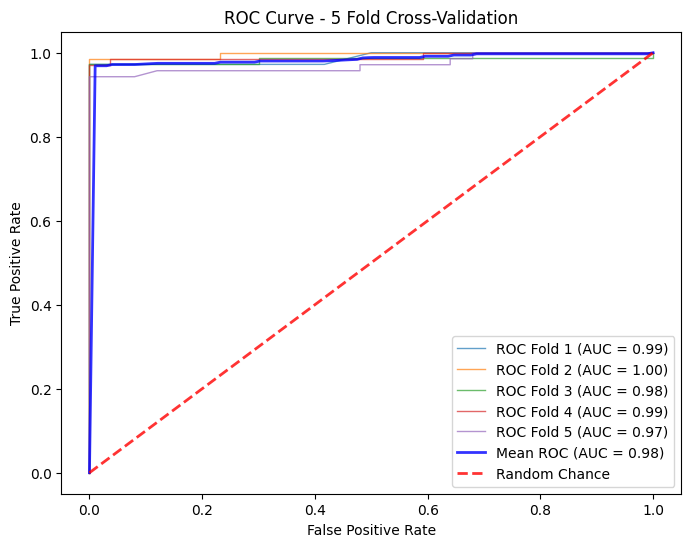

In [129]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [130]:
y.value_counts()

1    355
0    122
Name: Diagnosis, dtype: int64

In [131]:
Thoda rest karlijiye warn rest in peace ho jayegene

SyntaxError: invalid syntax (119544997.py, line 1)

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)



sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly



brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))